# 06 - Wizualizacja z `seaborn`

![seaborn_wiz](img/wiz_seaborn.png)

## W tym rozdziale

- Wprowadzenie do `seaborn`. 
- Zastosowanie `seaborn` w praktyce:
  - **Wykresy jednowymiarowe** (histogramy).  
  - **Dwuwymiarowe wykresy ciągłe** (scatterplots i wykresy liniowe).
  - **Dwuwymiarowe wykresy kategoryczne** (wykresy słupkowe, wykresy pudełkowe i wykresy paskowe).

![seaborn](img/seaborn.png)

## Wprowadzenie do `seaborn`

### Czym jest `seaborn`?

> [`seaborn`](https://seaborn.pydata.org/) jest pakietem do wizualizacji danych opartym na `matplotlib`.

- Ogólnie rzecz biorąc, łatwiej jest tworzyć ładnie wyglądające wykresy z `seaborn`.
- Kompromisem jest to, że `matplotlib` oferuje większą elastyczność.

In [1]:
import seaborn as sns ### ładowanie seaborn
import pandas as pd
import matplotlib.pyplot as plt ## gdyby był potrzebny
import numpy as np

In [2]:
%matplotlib inline 
%config InlineBackend.figure_format = 'retina'

### Hierarchia typów wykresów w `seaborn`

W tym rozdziale (i w następnym) dowiemy się więcej o tym, co dokładnie oznacza ta hierarchia.

![title](img/seaborn_library.png)

### Przykładowe dane

Tutaj zaczerpniemy z [Gapminder](https://www.gapminder.org/data/documentation/). 

- **Gapminder** to niezależna szwedzka fundacja zajmująca się publikowaniem i analizowaniem danych w celu korygowania błędnych przekonań na temat świata.
- W latach 1952-2007 posiadała dane na temat `life_exp`, `gdp_cap` i `population`.

In [3]:
df_gapminder = pd.read_csv("data/viz/gapminder_full.csv")

In [4]:
df_gapminder.head(2)

,country,year,population,continent,life_exp,gdp_cap
0,Afghanistan,1952,8425333,Asia,28.801,779.445314
1,Afghanistan,1957,9240934,Asia,30.332,820.853030


In [5]:
df_gapminder.shape

(1704, 6)

## Wykresy jednowymiarowe

> Wykres **jednowymiarowy** jest wizualizacją tylko *jednej* zmiennej, tj. jej **rozkładu**.

![title](img/displot.png)

### Histogramy z `sns.histplot`

- Poprzednio rysowaliśmy histogramy z `plt.hist`.  
- Z `seaborn`, mozemy uzyć `sns.histplot(...)`.

Zamiast `df['col_name']`, wykorzystujemy składnię:

```python
sns.histplot(data = dane, x = nazwa_zmiennej)
```

Stanie się to jeszcze bardziej przydatne, gdy zaczniemy tworzyć **wykresy dwuwymiarowe**.

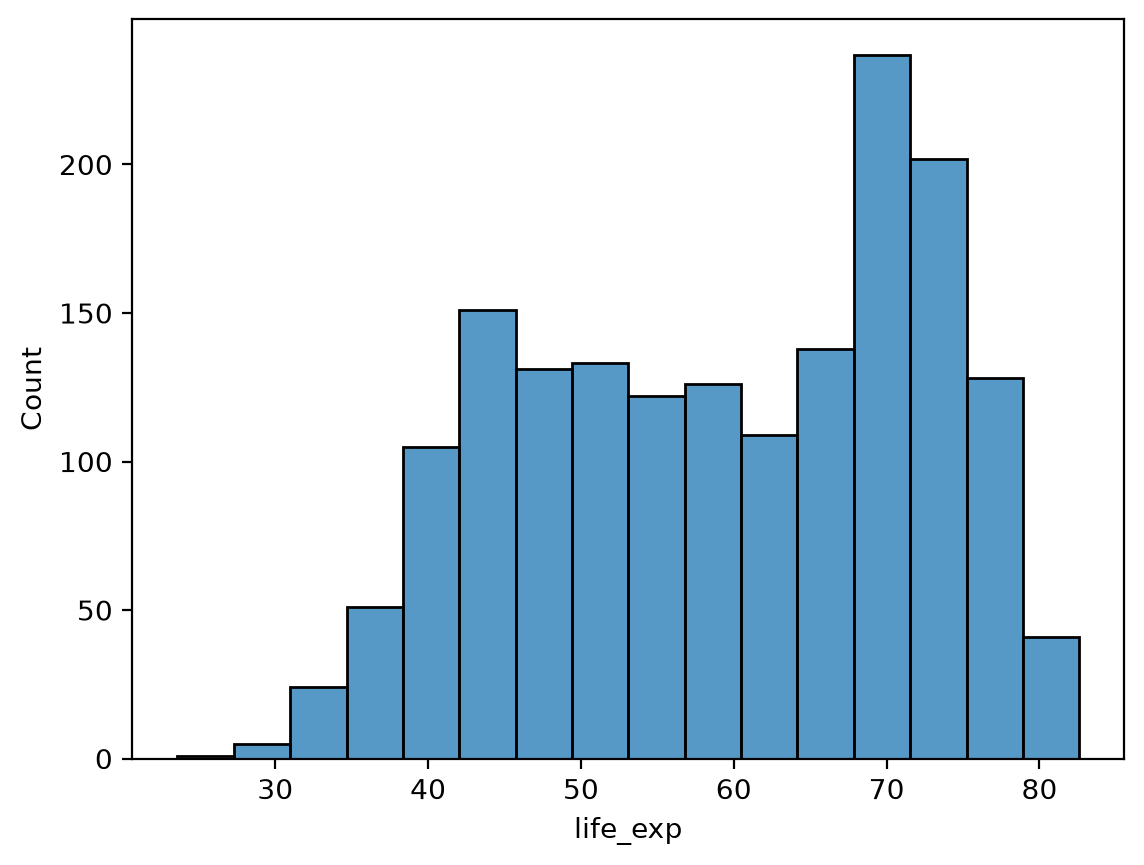

In [6]:
# Histogram oczekiwanej długości zycia
sns.histplot(df_gapminder['life_exp']);

#### Modyfikowanie liczby przedziałów

Podobnie jak w przypadku `plt.hist`, możemy modyfikować liczbę *przedziałów*.

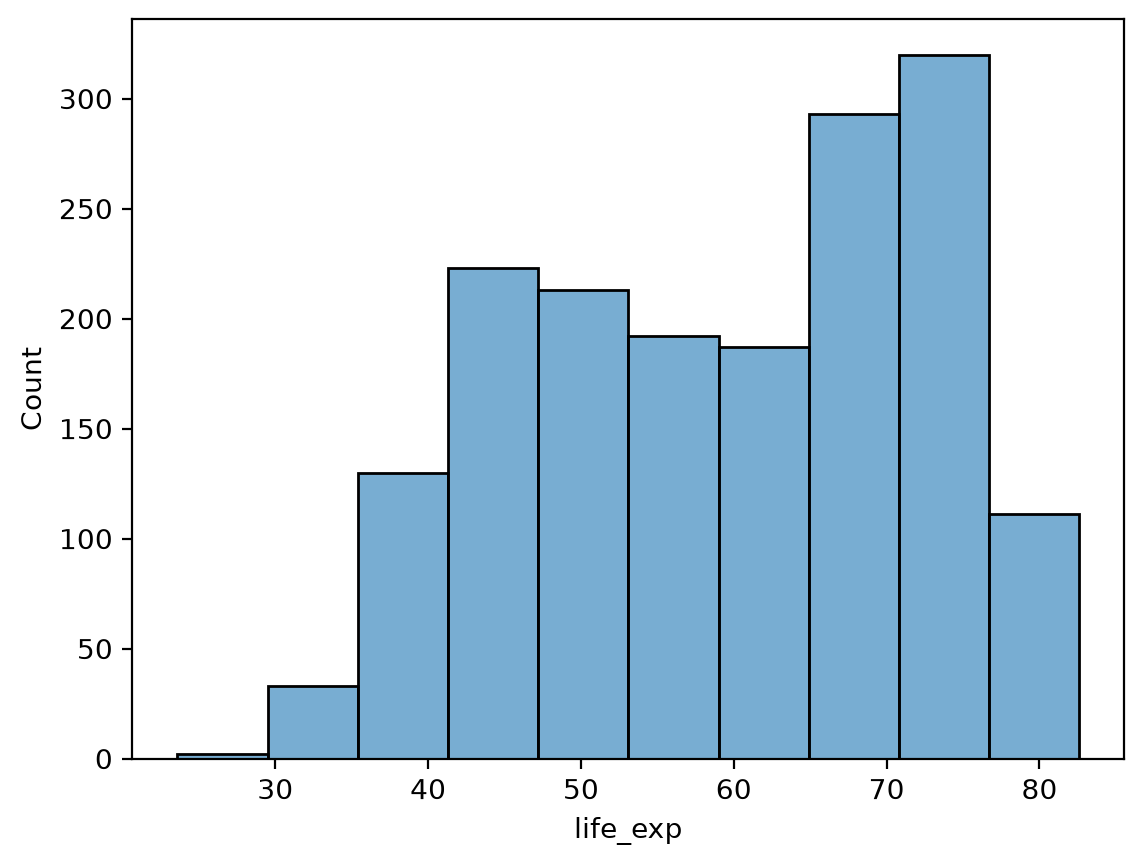

In [7]:
# Mniej przedziałów
sns.histplot(data = df_gapminder, x = 'life_exp', bins = 10, alpha = .6);

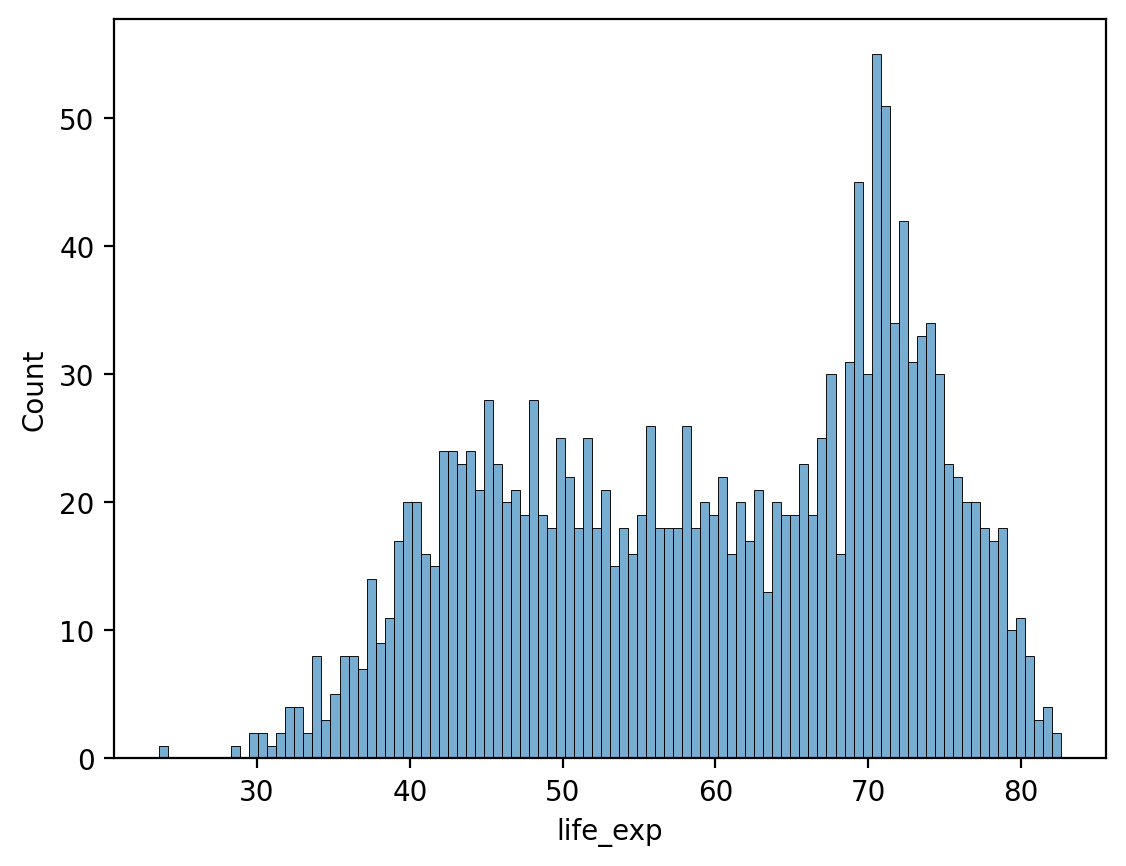

In [10]:
# Więcej przedziałów!
sns.histplot(data = df_gapminder, x = 'life_exp', bins = 100, alpha = .6);

#### Modyfikacje osi-y z `stat`

Domyślnie, `sns.histplot` wykreśli **liczebność** każdej kategorii. Możemy to jednak zmienić za pomocą parametru `stat`:

- `probability`: normalizuje tak, że wysokości słupków sumują się do `1`.
- `percent`: normalizuje tak, że wysokości słupków sumują się do `100`.
- `density`: normalizuje tak, że całkowita *area* sumuje się do `1`.


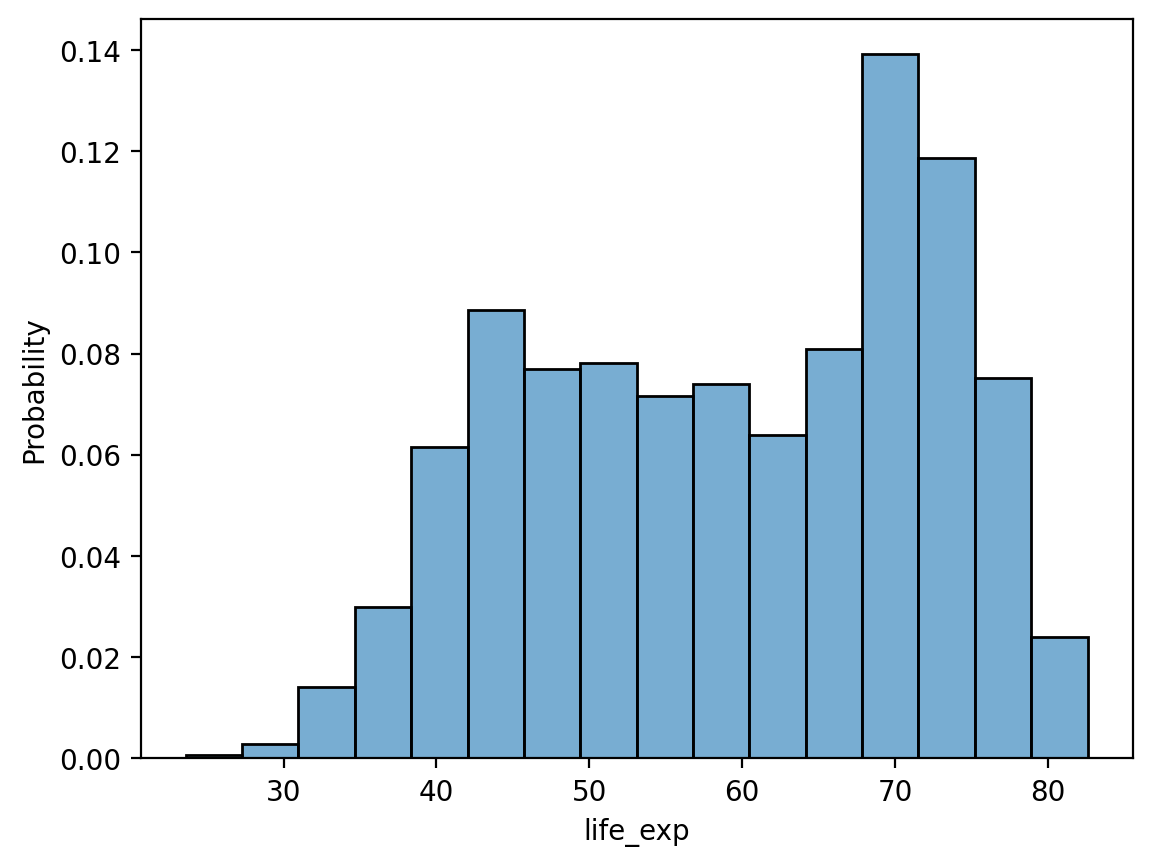

In [11]:
# Zwróć uwagę na zmodyfikowaną oś y!
sns.histplot(data = df_gapminder, x = 'life_exp', stat = "probability", alpha = .6);

### Sprawdź się!

Jak stworzyć histogram pokazujący rozkład wartości `population` w samym roku `2007`? 

- Zmodyfikuj ten wykres, aby pokazywał „prawdopodobieństwo”, a nie „liczbę”.
- Co widzimy na tym wykresie i jak mógł(a)byś go zmienić?

In [ ]:
### Twój kod tutaj

## Ciągłe wykresy dwuwymiarowe

> Wykres **zmiennych ciągłych** wizualizuje związek między *dwoma zmiennymi ciągłymi*.

![title](img/seaborn_relplot.png)

### Wykresy rozrzutu z `sns.scatterplot`

> **Wykres rozrzutu** wizualizuje związek między dwiema zmiennymi ciągłymi.

- Każda obserwacja jest wykreślana jako pojedyncza kropka/znak. 
- Pozycja na osiach `(x, y)` odzwierciedla wartość tych zmiennych.

Jednym ze sposobów utworzenia scatterplot w `seaborn` jest użycie `sns.scatterplot`.

#### Zależność `gdp_cap` z `life_exp`

Czego dowiadujemy się o zmiennej `gdp_cap`?

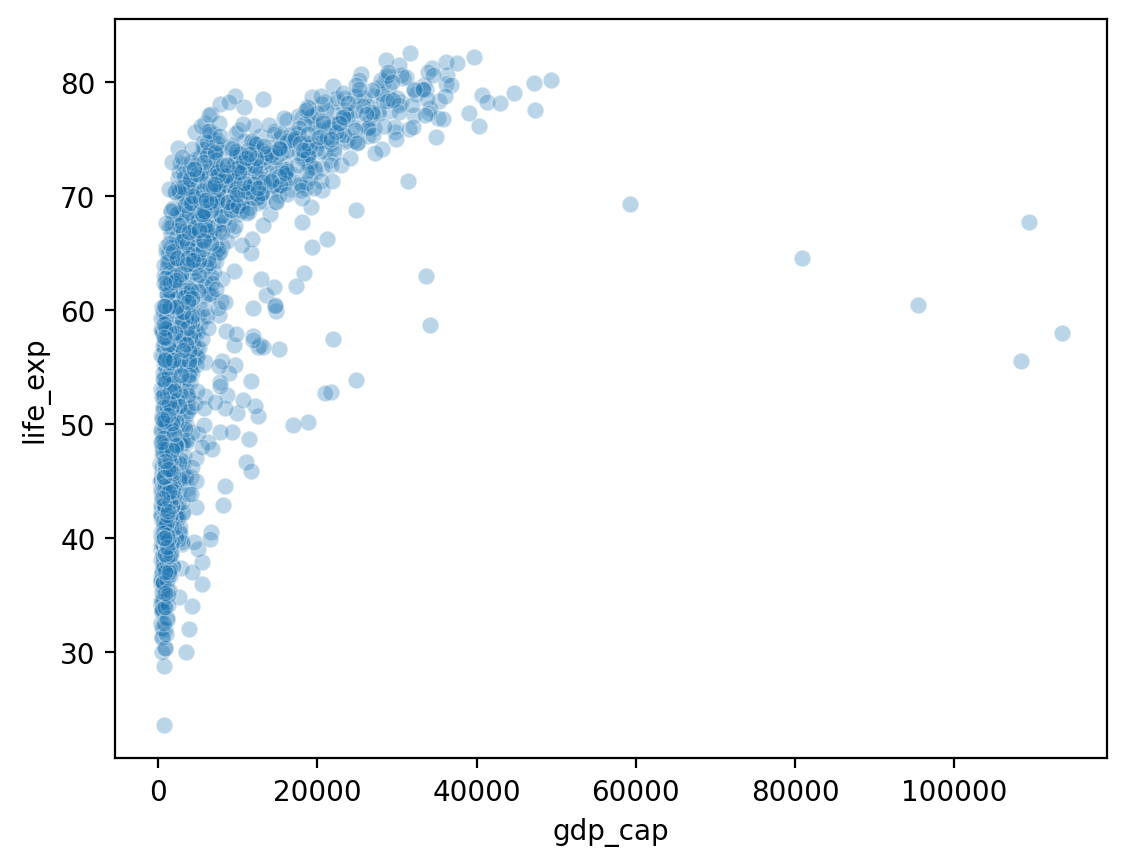

In [14]:
sns.scatterplot(data = df_gapminder, x = 'gdp_cap', y = 'life_exp', alpha = .3);

#### Zależność `gdp_cap_log` z `life_exp`

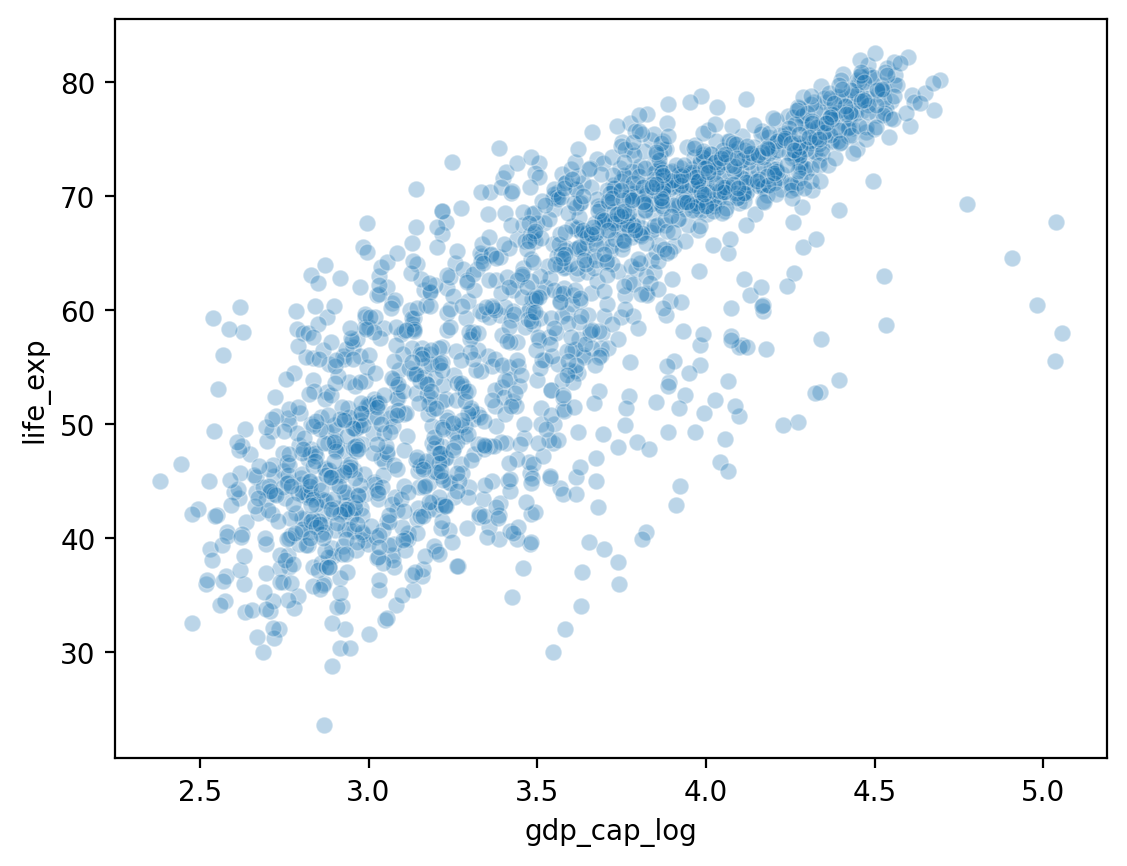

In [16]:
## Obliczamy i zapisujemy zmienną Log GDP
df_gapminder['gdp_cap_log'] = np.log10(df_gapminder['gdp_cap']) 
## Pokaż log GDP z life exp
sns.scatterplot(data = df_gapminder, x = 'gdp_cap_log', y = 'life_exp', alpha = .3);

#### Dodajemy `hue` - odcień

- Co jeśli chcemy dodać *trzeci* komponent, który jest kategoryczny, jak `continent`?
- `seaborn` pozwala nam to zrobić z `hue` - dodać odcienie.

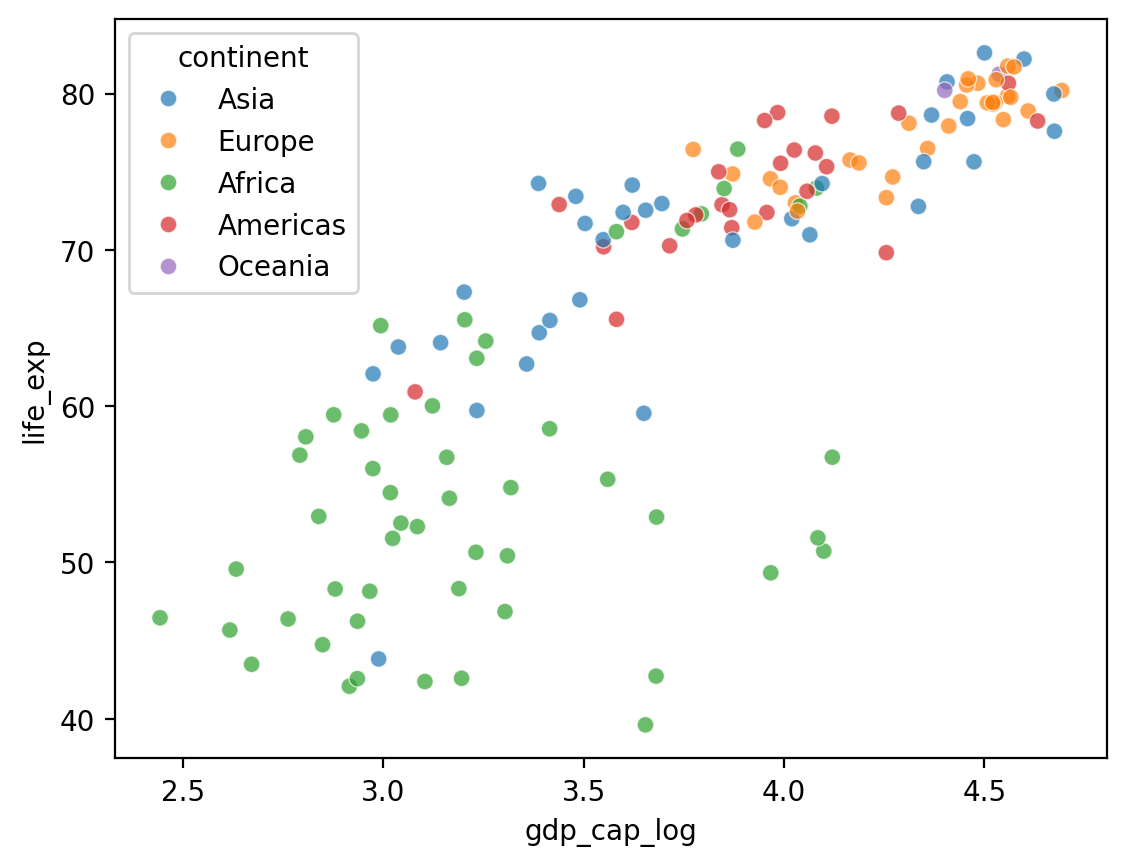

In [18]:
## Log GDP
df_gapminder['gdp_cap_log'] = np.log10(df_gapminder['gdp_cap']) 
## Pokaz log GDP z life exp
sns.scatterplot(data = df_gapminder[df_gapminder['year'] == 2007],
               x = 'gdp_cap_log', y = 'life_exp', hue = "continent", alpha = .7);

#### Dodajemy `size`

- Co jeśli chcemy dodać *czwarty* komponent, który jest ciągły, jak `population`?
- `seaborn` pozwala nam to zrobić z `size` - powstanie wykres bąbelkowy!

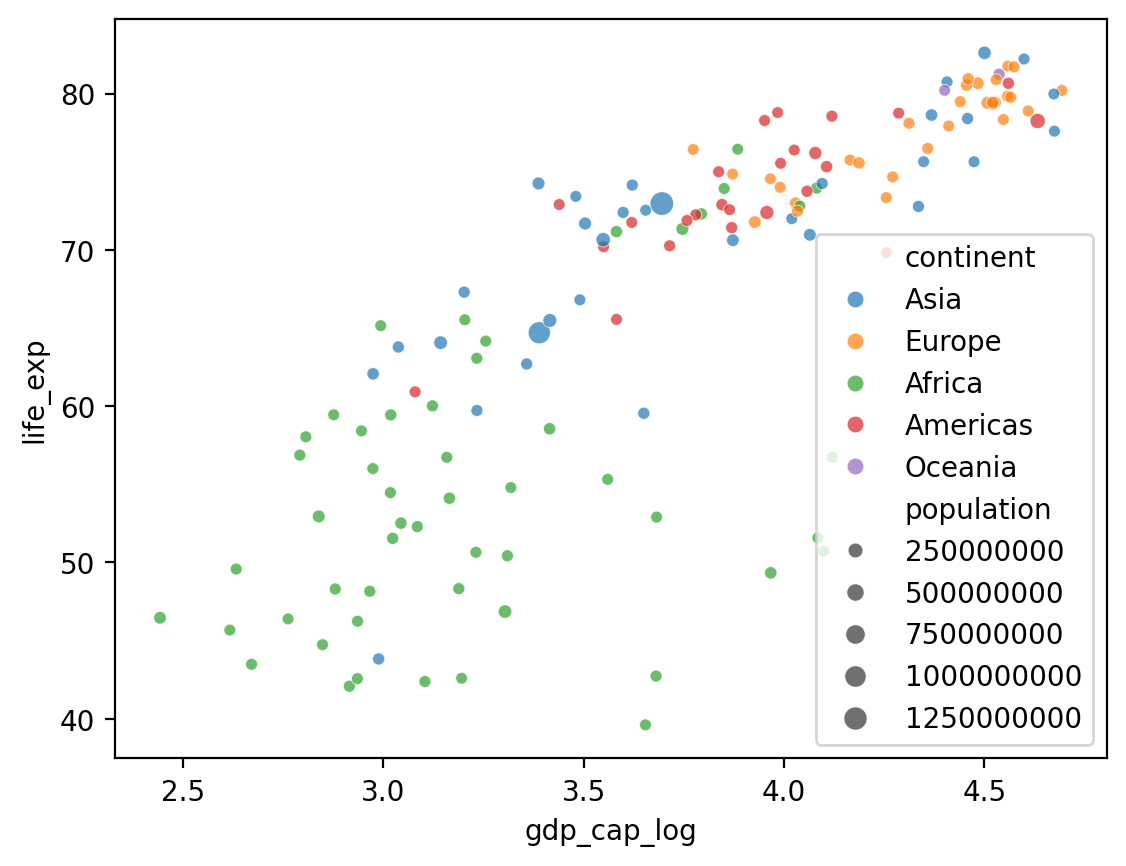

In [20]:
## Log GDP
df_gapminder['gdp_cap_log'] = np.log10(df_gapminder['gdp_cap']) 
## Pokaz log GDP z life exp
sns.scatterplot(data = df_gapminder[df_gapminder['year'] == 2007],
               x = 'gdp_cap_log', y = 'life_exp',
                hue = "continent", size = 'population', alpha = .7);

#### Zmiany w pozycji legendy

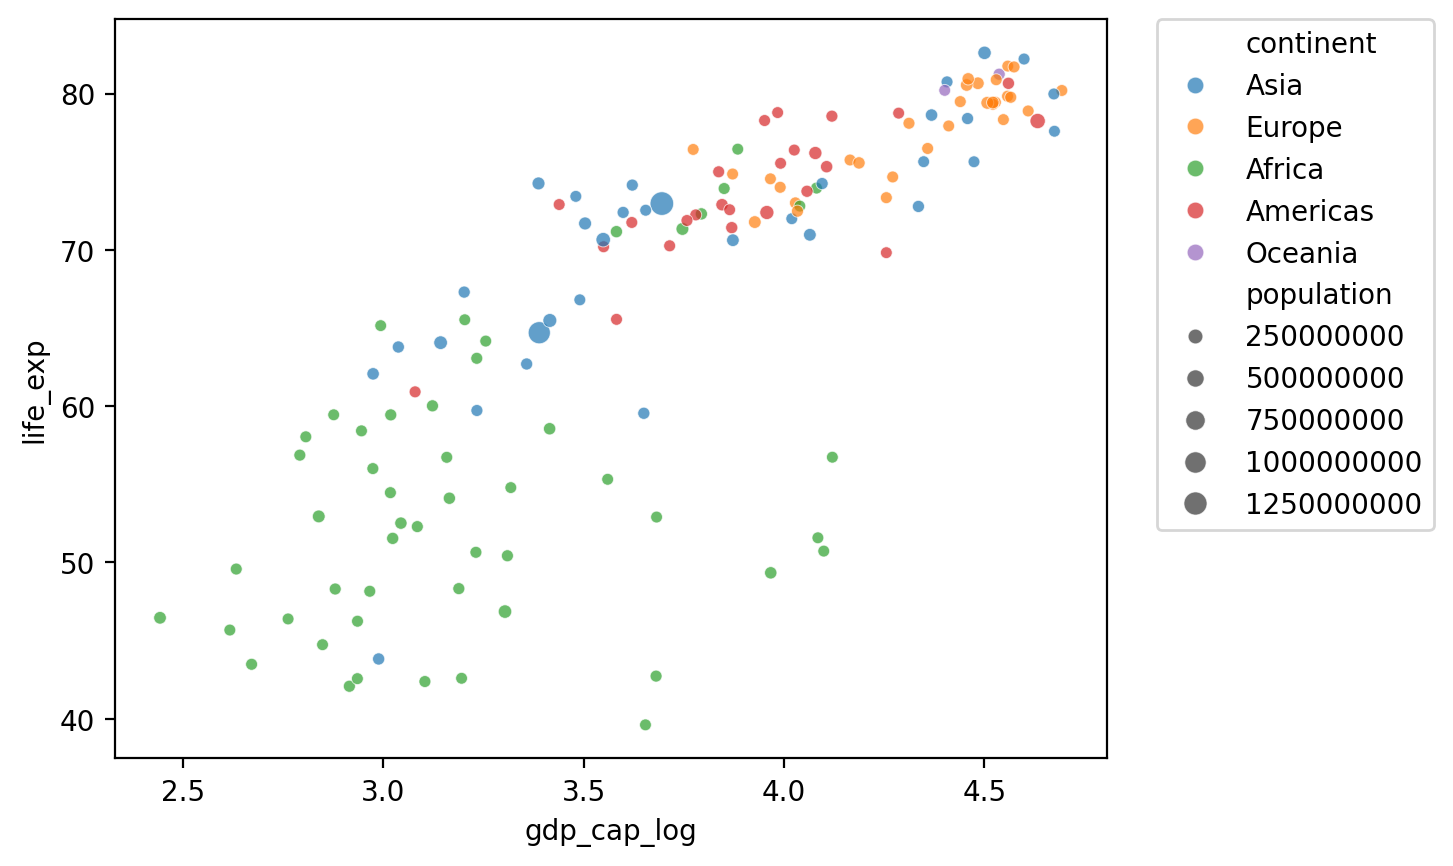

In [22]:
## Pokaz log GDP z life exp
sns.scatterplot(data = df_gapminder[df_gapminder['year'] == 2007],
               x = 'gdp_cap_log', y = 'life_exp',
                hue = "continent", size = 'population', alpha = .7)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0);

### Wykres liniowy z `sns.lineplot`

> **Wykres liniowy** równiez wizualizuje związek między dwiema zmiennymi ciągłymi.

- Zazwyczaj pozycja linii na osi `y` odzwierciedla *średnią* zmiennej na osi `y` dla tej wartości `x`.
- Często używany do wykreślania **zmian w czasie**.

Jednym ze sposobów na stworzenie wykresu liniowego w `seaborn` jest użycie [`sns.lineplot`](https://seaborn.pydata.org/generated/seaborn.lineplot.html).

#### Wykres `life_exp` oraz `year`

Jaki ogólny trend zauważamy?

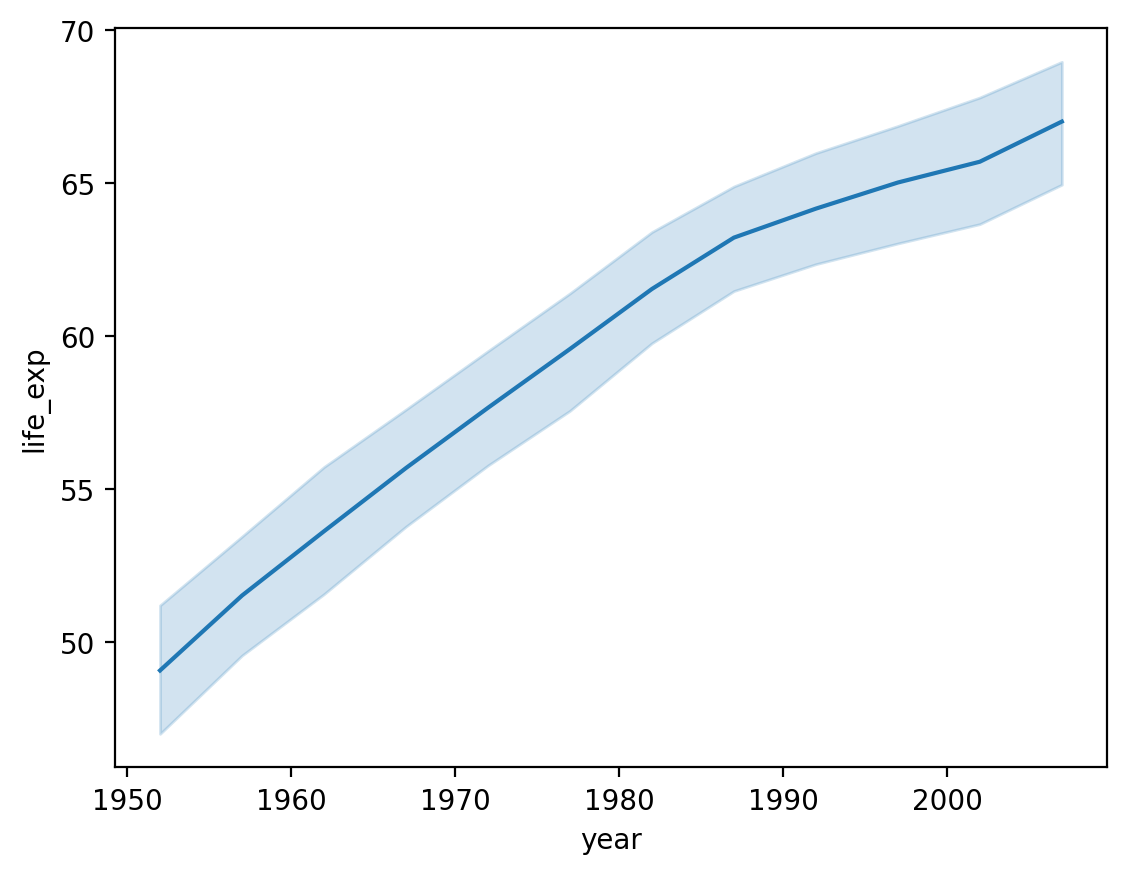

In [23]:
sns.lineplot(data = df_gapminder,
             x = 'year',
             y = 'life_exp');

#### Modyfikowanie sposobu wyświetlania błędów/niepewności

- Domyślnie, `seaborn.lineplot` rysuje **cieniowanie** wokół linii reprezentującej przedział ufności.
- Możemy to zmienić za pomocą `errstyle`.

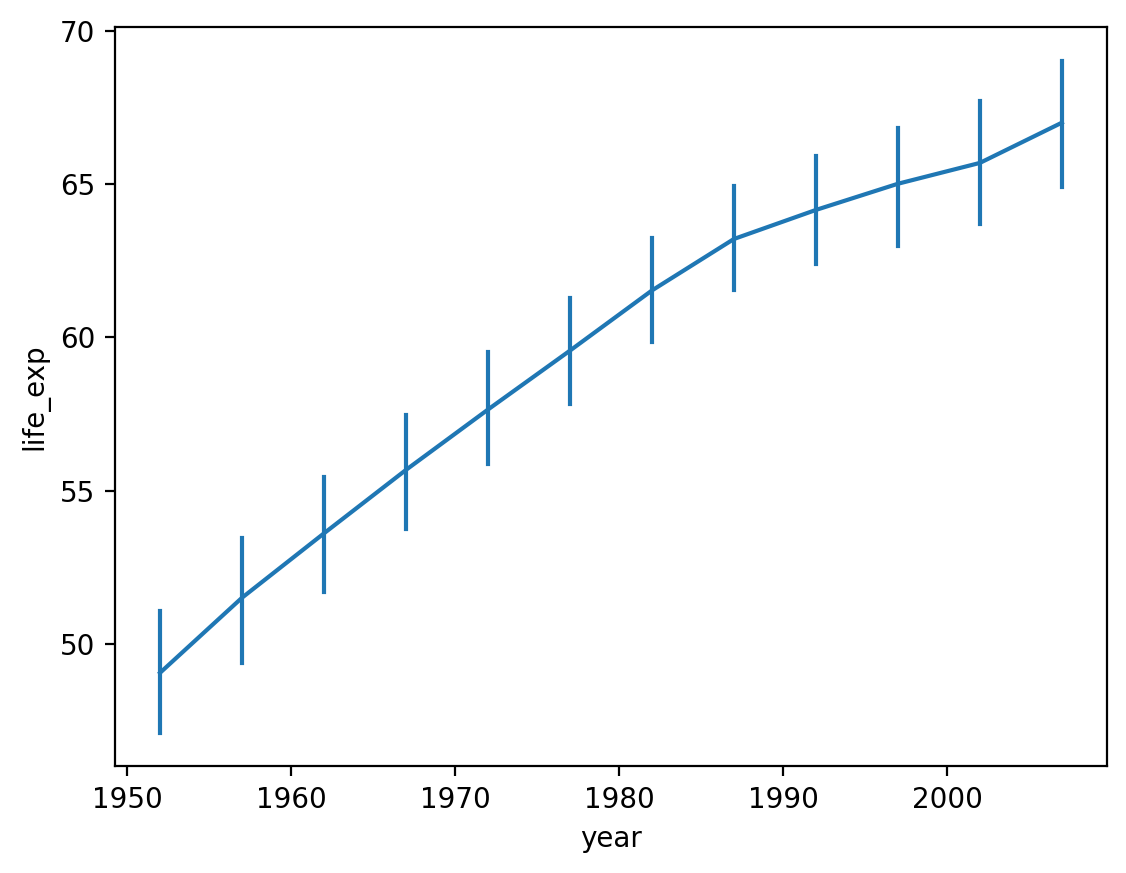

In [25]:
sns.lineplot(data = df_gapminder,
             x = 'year',
             y = 'life_exp',
            err_style = "bars");

#### Dodawanie `hue`

- Moglibyśmy również pokazać to według `kontynentów`.  
- Istnieje (na szczęście) pozytywna linia trendu dla każdego `kontynentu`.

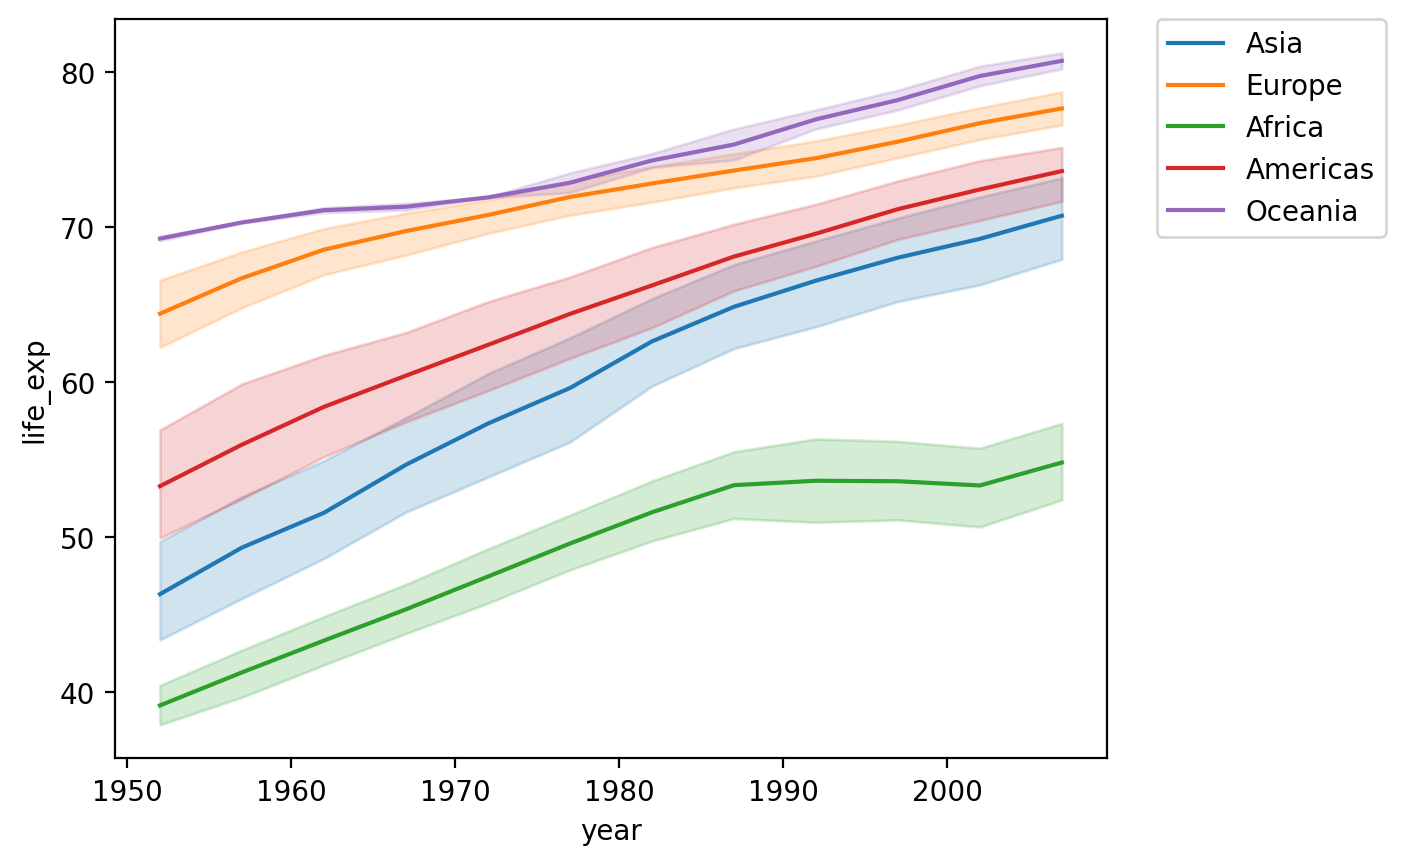

In [26]:
sns.lineplot(data = df_gapminder,
             x = 'year',
             y = 'life_exp',
            hue = "continent")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0);

#### Sprawdź się!

Jak wykreślić zależność między `year` i `gdp_cap` tylko dla krajów w obu Amerykach?

In [ ]:
### Twój kod tutaj

#### Heteroskedastyczność w `gdp_cap` według `roku`

- [**Heteroskedastyczność**](https://en.wikipedia.org/wiki/Homoscedasticity_and_heteroscedasticity) to sytuacja, w której *zmienność* jednej zmiennej (np. `gdp_cap`) zmienia się w funkcji innej zmiennej (np. `roku`).
- Jak myślisz, dlaczego tak jest w tym przypadku?

#### Rysowanie według kraju

- Jest zbyt wiele krajów, aby wyraźnie wyświetlić je w `legendzie`. 
- Ale dwie górne linie to „Stany Zjednoczone” i „Kanada”.
   - Oznacza to, że dwa kraje stały się znacznie bogatsze w przeliczeniu na mieszkańca, podczas gdy inne nie odnotowały takiego samego wzrostu gospodarczego.

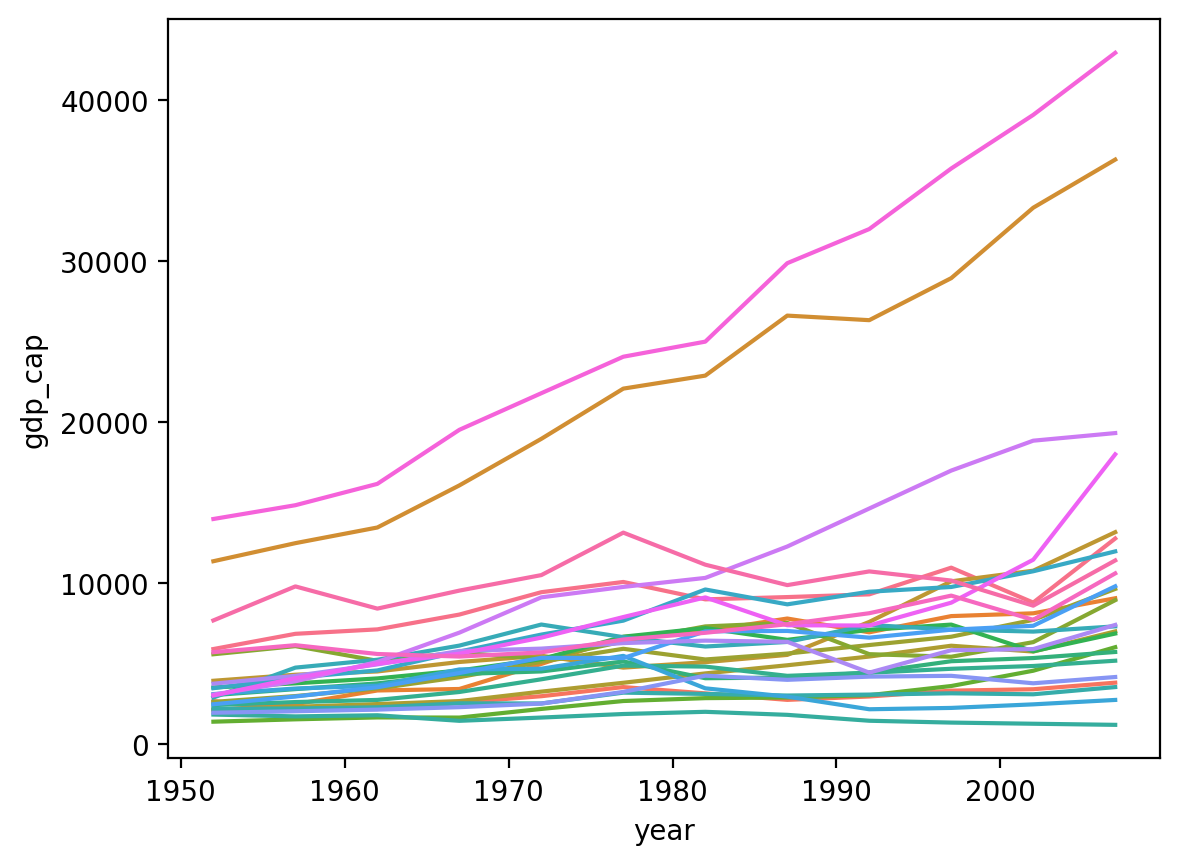

In [28]:
sns.lineplot(data = df_gapminder[df_gapminder['continent']=="Americas"],
             x = 'year', y = 'gdp_cap', hue = "country", legend = None);

### Wykorzystanie `relplot`

- `relplot` pozwala na tworzenie wykresów liniowych lub wykresów rozproszonych przy użyciu `kind`.
- `relplot` ułatwia również `facet` (który omówimy za chwilę).

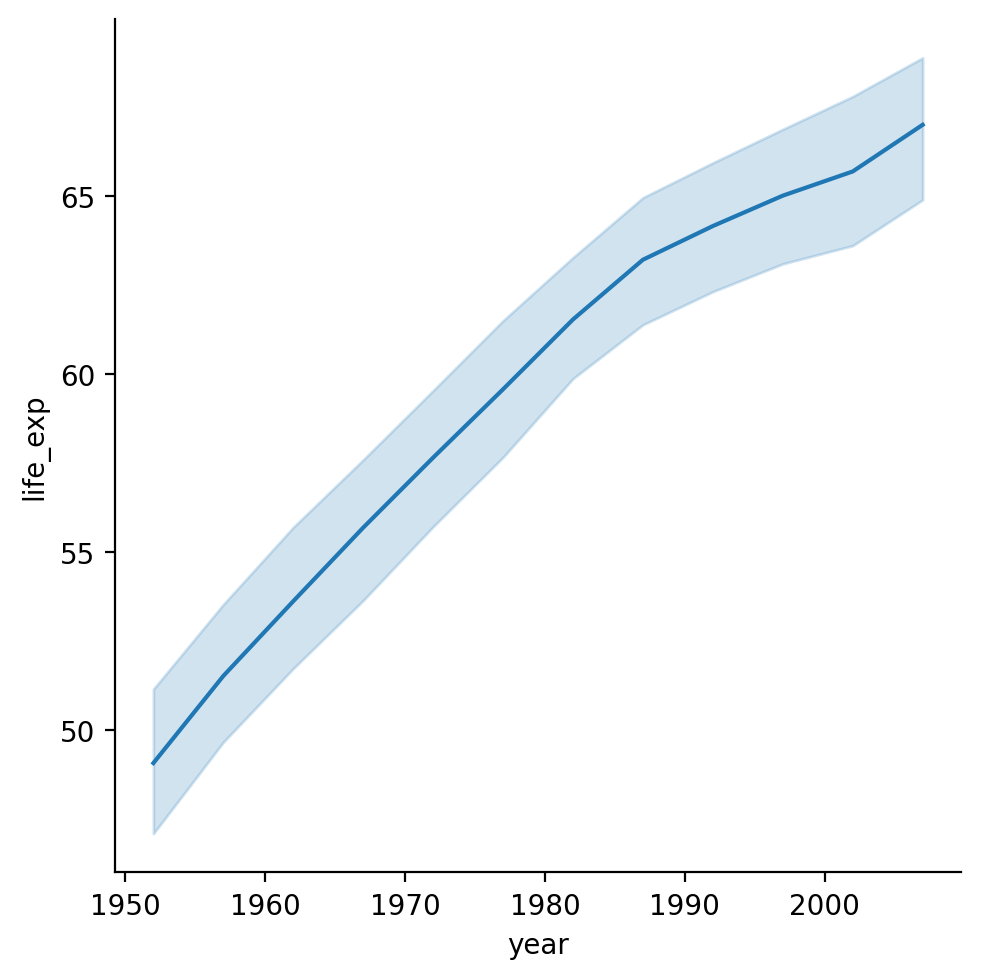

In [29]:
sns.relplot(data = df_gapminder, x = "year", y = "life_exp", kind = "line");

#### Grupowanie grafik w `wiersze` i `kolumny`

Możemy również wykreślić tę samą relację w wielu „oknach” lub **facetach**, dodając parametr `rows`/`cols`.

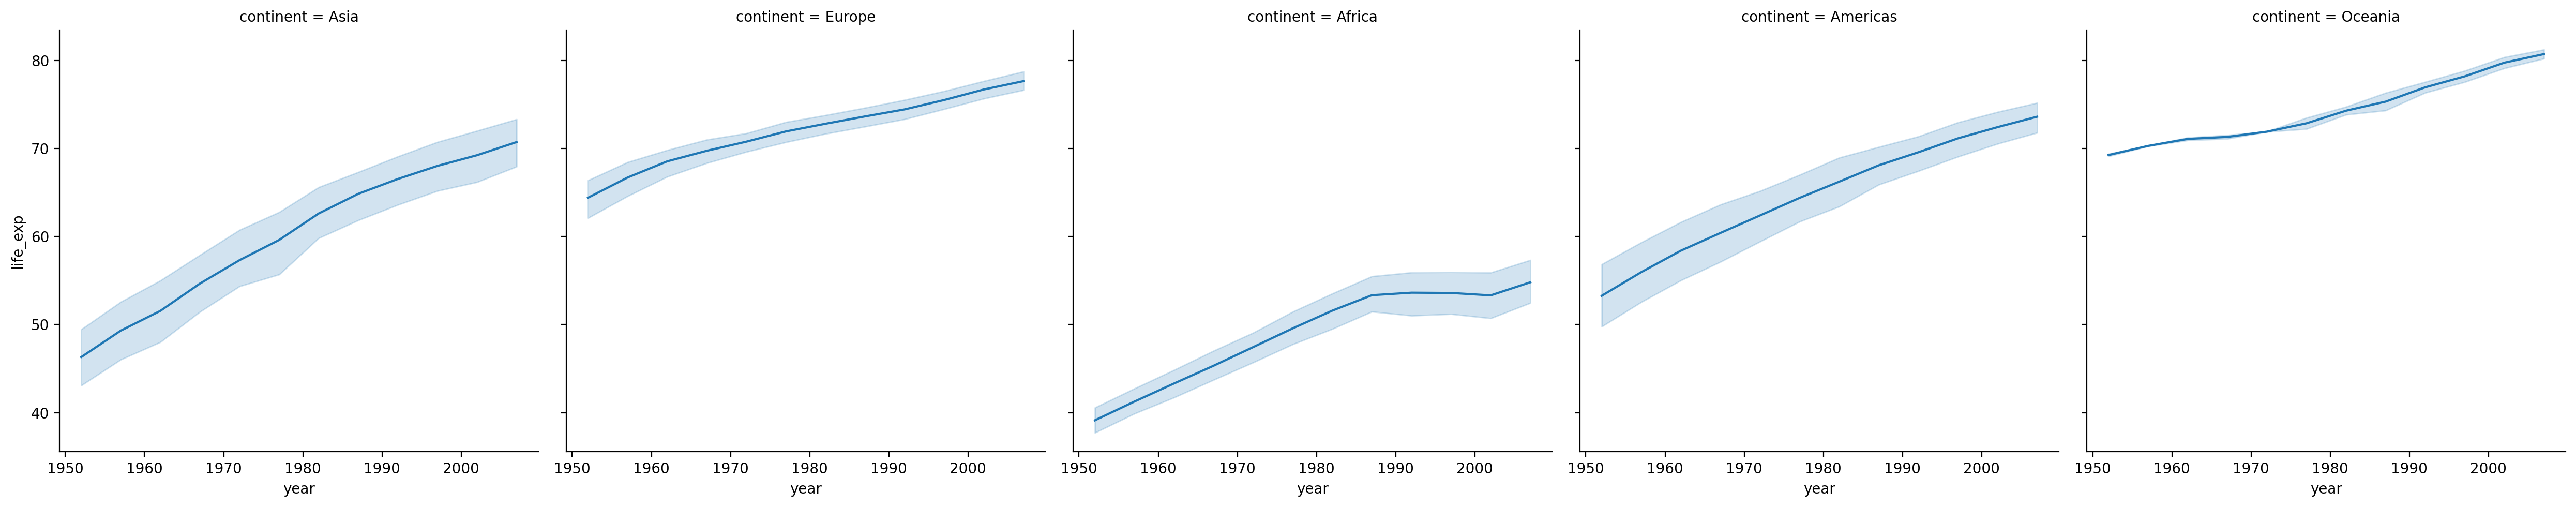

In [30]:
sns.relplot(data = df_gapminder, x = "year", y = "life_exp", kind = "line", col = "continent");

## Dwuwymiarowe wykresy kategoryczne

> **Dwuwymiarowy wykres kategoryczny** przedstawia (ewentualny) związek pomiędzy jedną zmienną kategoryczną (jakościową) a jedną zmienną ciągłą (ilościową).

![title](img/seaborn_catplot.png)

### Przykładowe dane

W tym miejscu powrócimy do naszego zbioru danych Pokemon, który zawiera więcej przykładów zmiennych kategorialnych.

In [8]:
df_pokemon = pd.read_csv("data/pokemon.csv")

### Wykresy słupkowe `sns.barplot`

> **Wykres słupkowy** wizualizuje związek pomiędzy jedną *zmienną ciągłą* a *zmienną kategorialną*.

- *Wysokość* każdego słupka zazwyczaj wskazuje średnią zmiennej ciągłej.
- Każdy słupek reprezentuje inny *poziom* zmiennej kategorialnej.

Z `seaborn`, możemy użyć funkcji `sns.barplot`.

#### Średni `Attack` według statusu `Legendary`

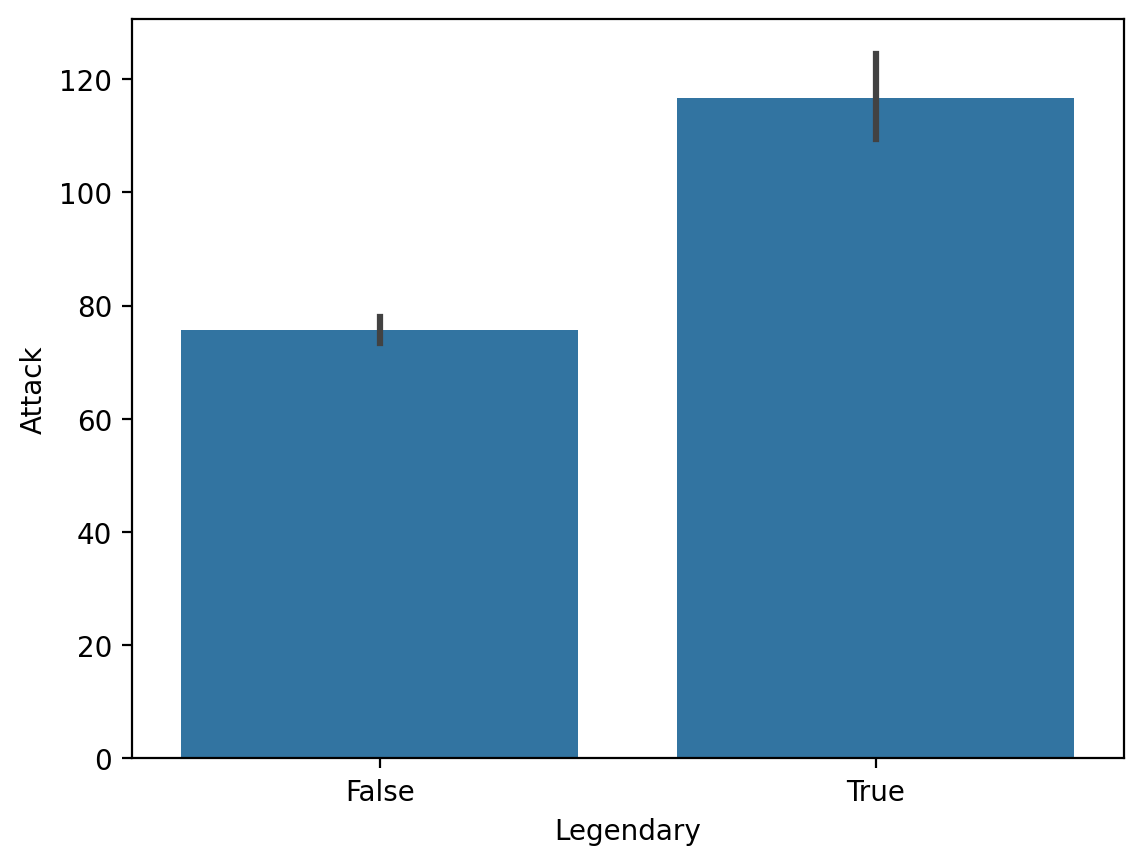

In [33]:
sns.barplot(data = df_pokemon,
           x = "Legendary", y = "Attack");

#### Średni `Attack` według `Type 1`

Zauważ, że rysunek jest *większy*, aby upewnić się, że wszystkie etykiety pasują.

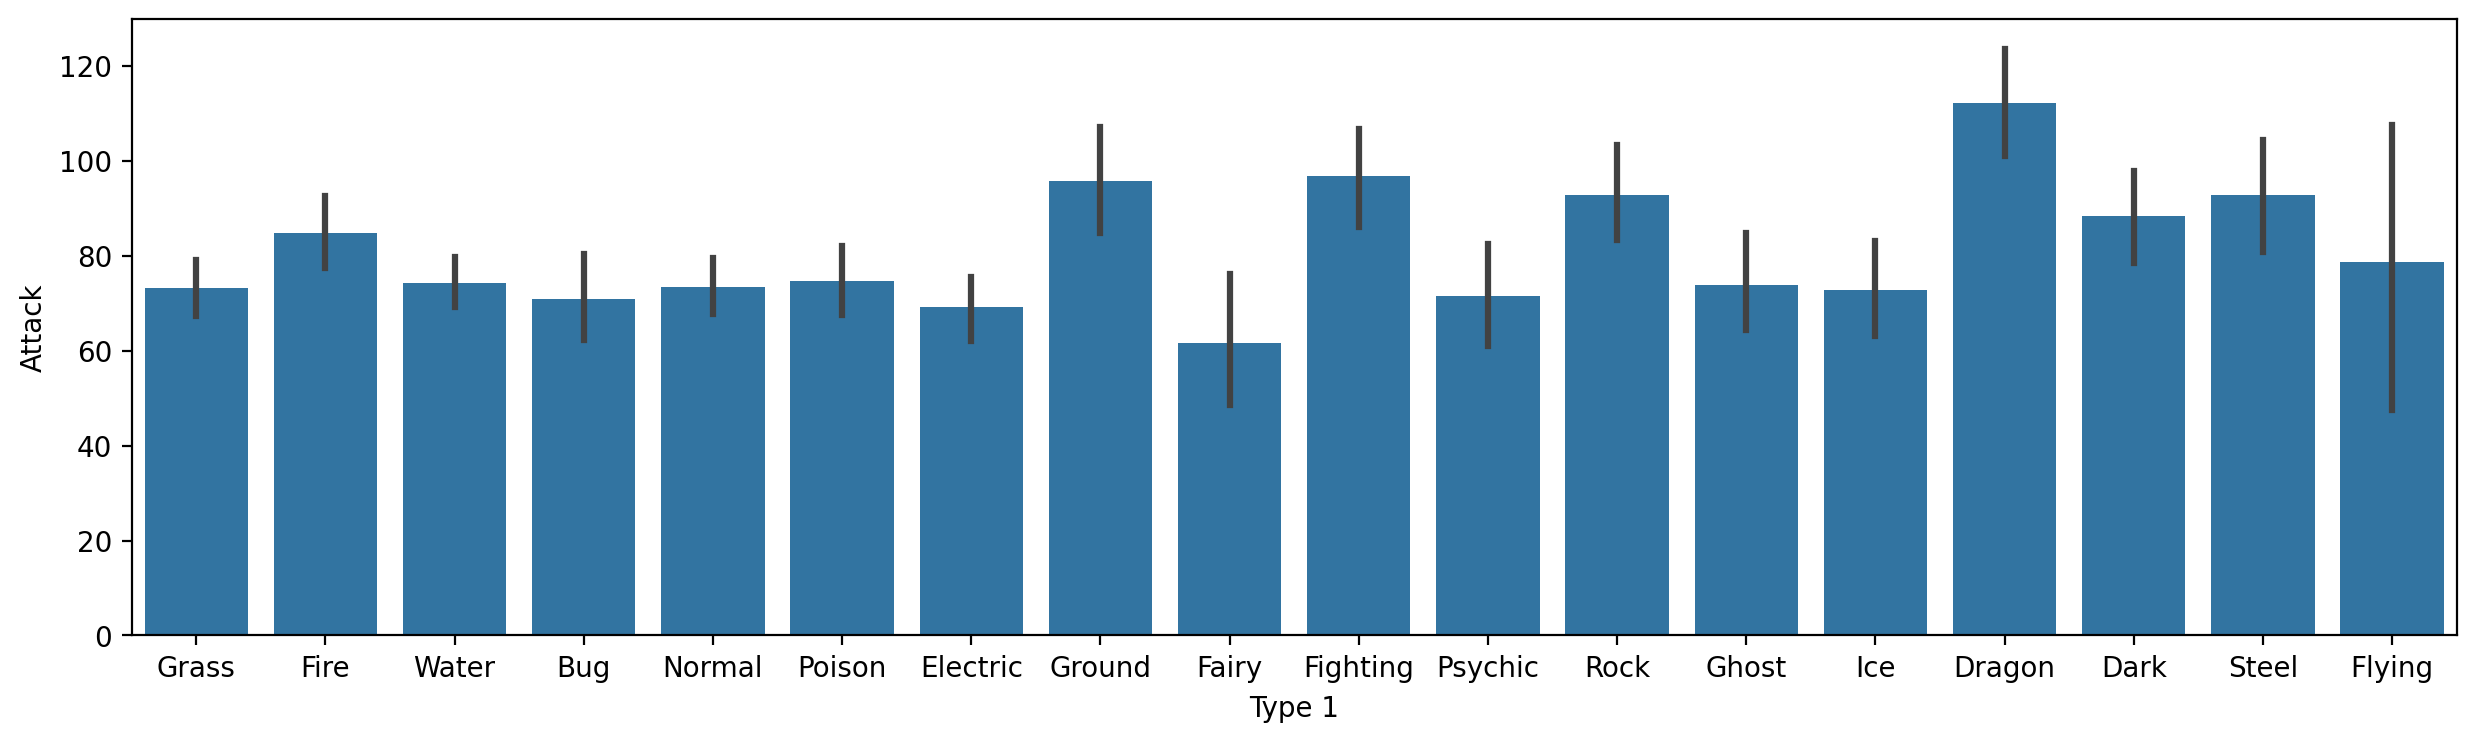

In [35]:
plt.figure(figsize=(15,4))
sns.barplot(data = df_pokemon,
           x = "Type 1", y = "Attack");

#### Sprawdź się

Jak wykreślić `HP` według `Type 1`?

In [ ]:
### Twój kod tutaj

#### Modyfikowanie `hue`

Podobnie jak w przypadku `wykresu rozrzutu` i `liniowego`, możemy zmienić `hue`, aby uzyskać większą przejrzystość.

- Na przykład, `HP` przez `Type 1`, dalej podzielone przez status `Legendary`.

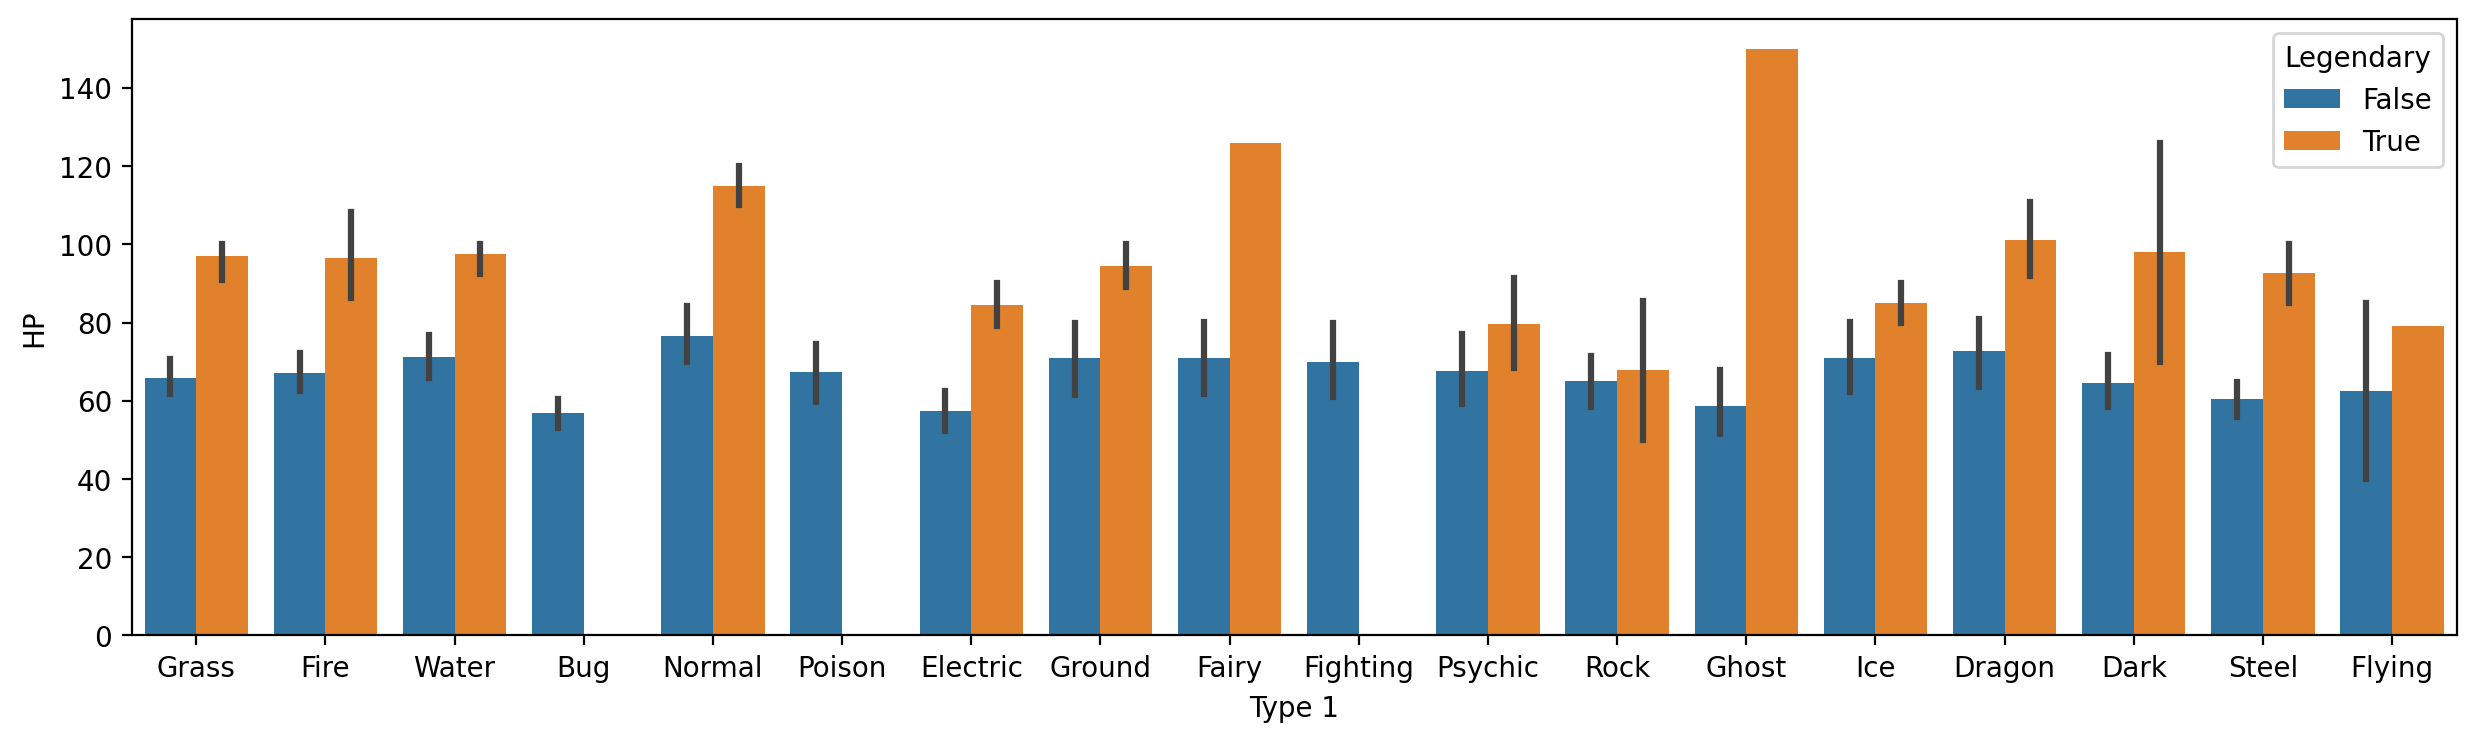

In [36]:
plt.figure(figsize=(15,4))
sns.barplot(data = df_pokemon,
           x = "Type 1", y = "HP", hue = "Legendary");

### Wykorzystanie `catplot`

> `seaborn.catplot` jest wygodną funkcją do wykreślania dwuwymiarowych danych kategorycznych przy użyciu szeregu typów wykresów (`bar`, `box`, `strip`).

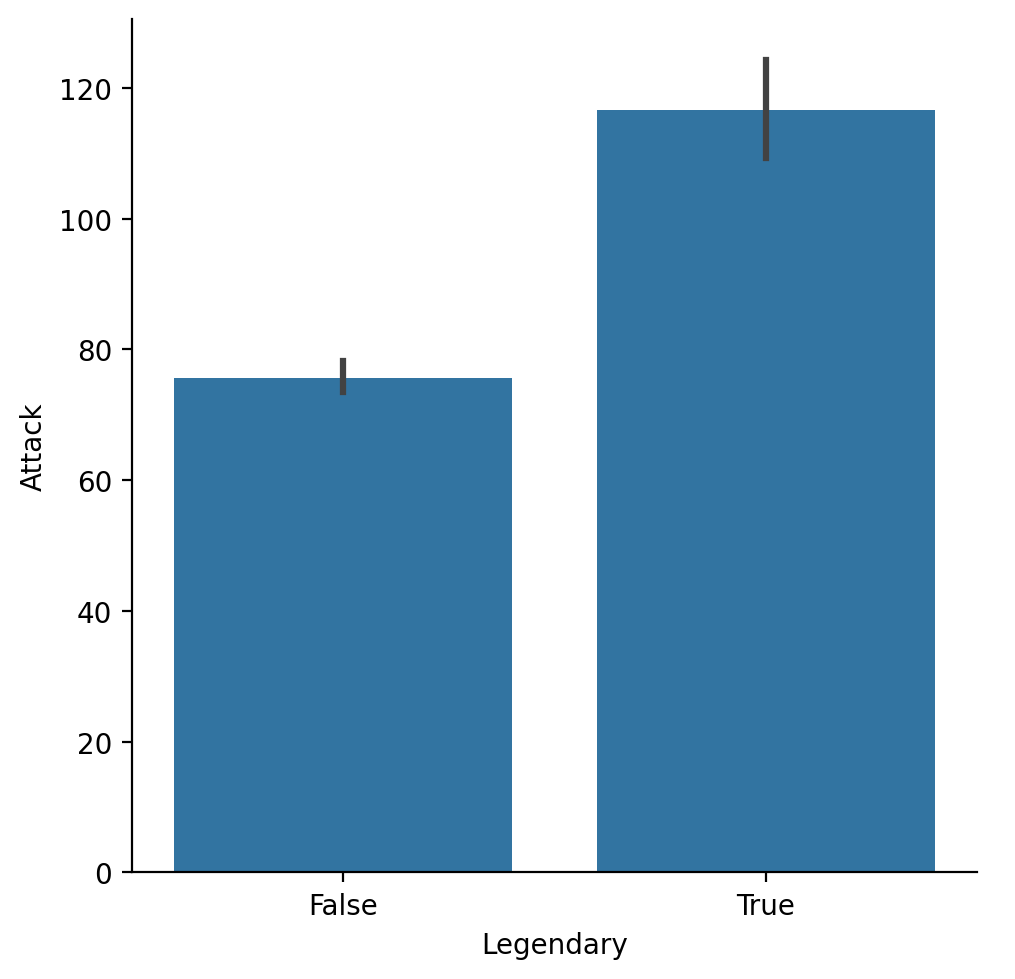

In [ ]:
sns.catplot(data = df_pokemon, x = "Legendary", 
             y = "Attack", kind = "bar");

#### Wykresy paskowe

> Wykres **paskowy** pokazuje każdy pojedynczy punkt (jak scatterplot), podzielony przez **etykietę kategorii**.

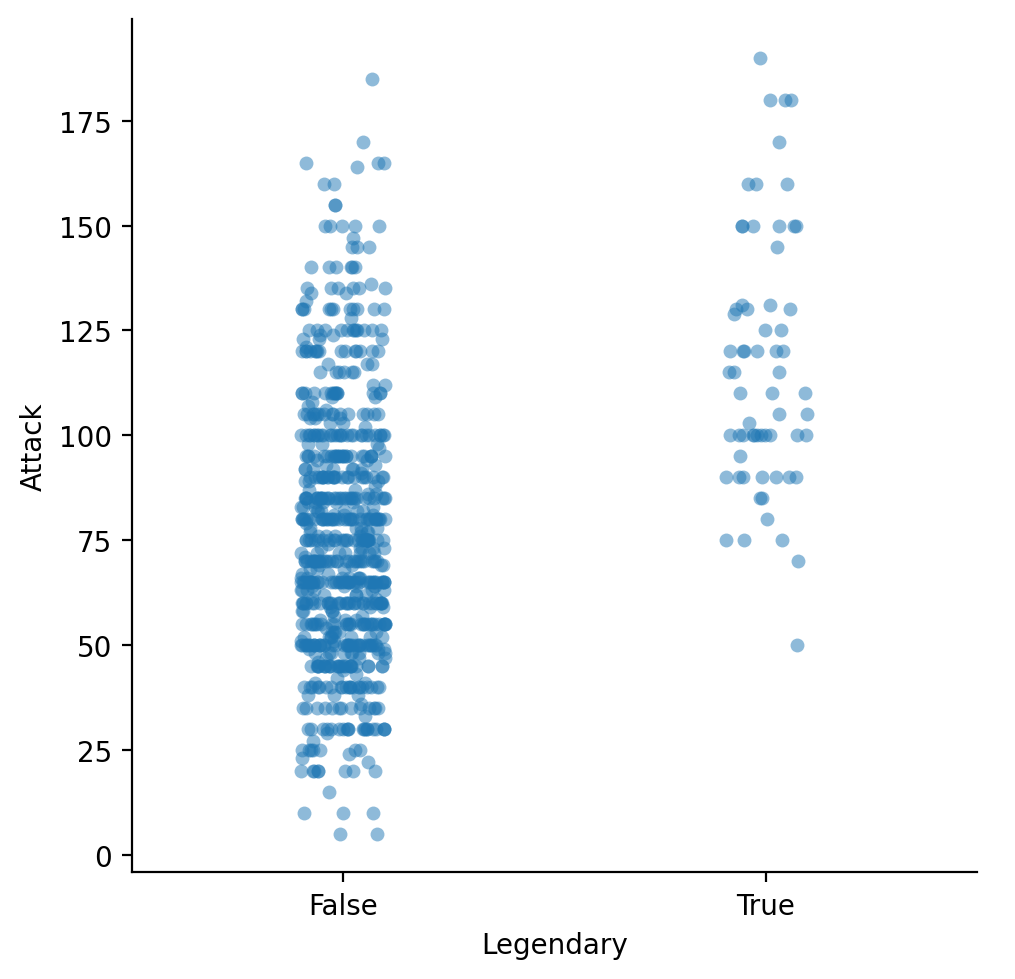

In [38]:
sns.catplot(data = df_pokemon, x = "Legendary", 
             y = "Attack", kind = "strip", alpha = .5);

#### Dodanie `średniej` do wykresu `paskowego`

Możemy wykreślić *dwa wykresy* w tym samym czasie, pokazując zarówno poszczególne punkty, jak i średnie.

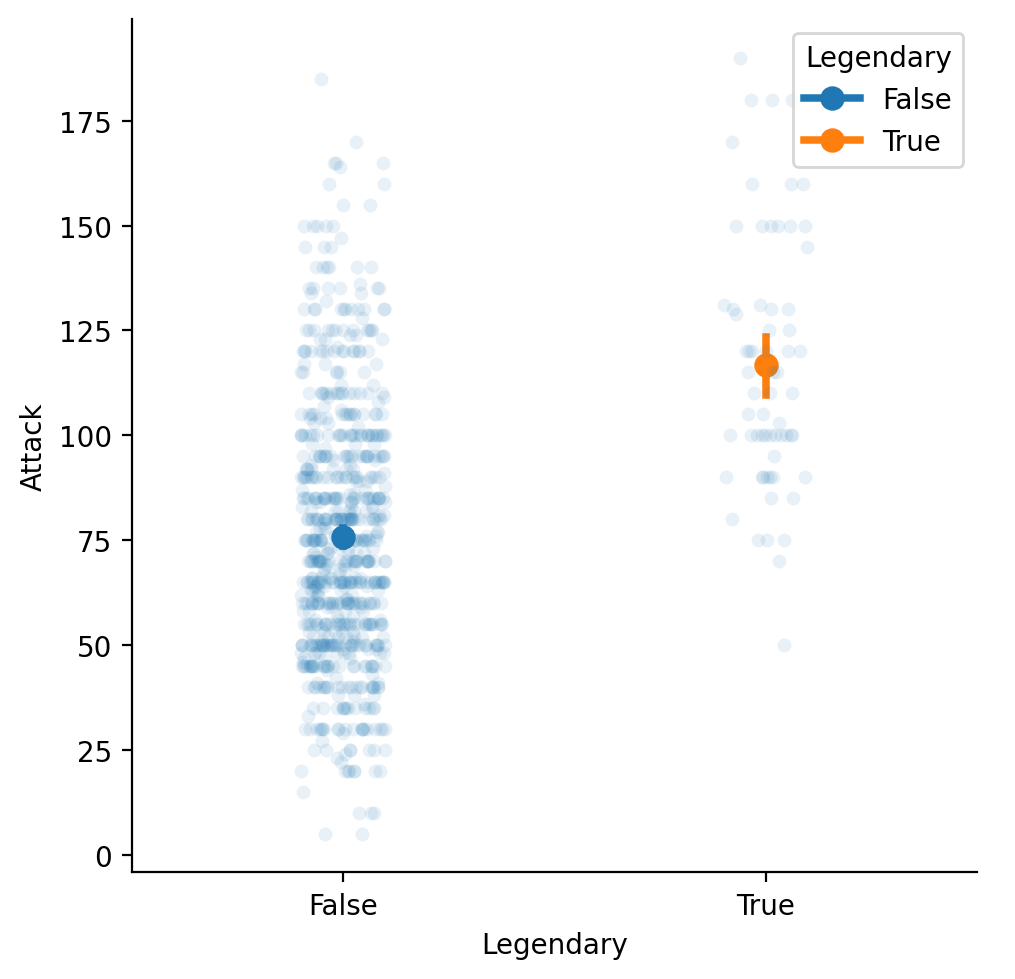

In [40]:
sns.catplot(data = df_pokemon, x = "Legendary", 
             y = "Attack", kind = "strip", alpha = .1);
sns.pointplot(data = df_pokemon, x = "Legendary", 
             y = "Attack", hue = "Legendary");

#### Wykresy `pudełkowe`

> Wykres **pudełkowy** w teorii pokazuje zakres międzykwartylowy (środkowe 50% danych), medianę wraz z minimum i maksimum.

Typowy **boxplot** zawiera kilka komponentów, które są częścią jego anatomii:

- Mediana: Jest to środkowa wartość danych, reprezentowana przez linię w ramce.
- Ramki: Reprezentują one zakres międzykwartylowy danych (IQR), który reprezentuje zakres między Q1 i Q3. Dolna i górna krawędź reprezentują odpowiednio Q1 i Q3.
- Wąsy: Są to pionowe linie, które rozciągają się od obu końców pudełka, aby reprezentować wartości minimalne i maksymalne, z wyłączeniem wartości odstających.
- Wartości odstające: Są to punkty poza wąsami uważane za nietypowe lub skrajne w porównaniu z resztą danych.
- Ograniczniki: Są to poziome linie na końcach wąsów, reprezentujące wartości minimalne i maksymalne, w tym wszelkie wartości odstające.

**Czy wąsy pokazują minimum i maksimum?**

Z punktu widzenia statystyki - końcówki wąsów nie są więc min oraz max - ponieważ nie zawierają części nietypowych wartości. 

*Standardowe zasady:*

- **Wartości odstające (outliers):** Są to punkty znajdujące się poza zakresem wąsów. Wartości te są uznawane za nietypowe w porównaniu do reszty danych.
- **Zakres wąsów:** Wąsy rozciągają się do wartości, które mieszczą się w granicach:
  - Dolny wąs: $Q1 - 1.5 * IQR$
  - Górny wąs: $Q3 + 1.5 * IQR$
- **Ekstremalne wartości odstające:** Jeśli wartości znajdują się znacznie dalej poza wąsami (np. $Q1 - 3 * IQR$ lub $Q3 + 3 * IQR$), mogą być uznane za ekstremalne odstające.

Wartości odstające są zazwyczaj wyświetlane jako pojedyncze punkty na wykresie pudełkowym, co pozwala na ich łatwą identyfikację.

**Dlaczego wartości odstające są ważne?**

- Mogą wskazywać na błędy w danych (np. literówki, błędy pomiarowe).
- Mogą reprezentować rzeczywiste, ale rzadkie zdarzenia, które warto zbadać.
- Wartości odstające mogą znacząco wpływać na statystyki opisowe, takie jak średnia, dlatego ich identyfikacja jest kluczowa w analizie danych.

**Dlaczego 1,5 × IQR?**

$1,5$ × $IQR$ to standardowa wartość używana do identyfikacji umiarkowanych wartości odstających.

Rozstęp międzykwartylowy (IQR) to różnica między trzecim kwartylem (Q3) a pierwszym kwartylem (Q1), czyli zakres, w którym znajduje się środkowe 50% danych.

Wartości, które znajdują się poza zakresem:

- Dolny próg: $Q1$ - $1.5$ × $IQR$
- Górny próg: $Q3$ + $1.5$ × $IQR$ są uznawane za wartości odstające.

Wartość $1,5$ została wybrana empirycznie jako rozsądny kompromis między wykrywaniem wartości odstających a ignorowaniem naturalnych fluktuacji w danych.

**Dlaczego 3 × IQR?**

$3$ × $IQR$ jest używane do identyfikacji wartości ekstremalnych odstających, które są znacznie bardziej odległe od reszty danych.

Wartości poza zakresem:

- Dolny próg: $Q1$ - $3$ × $IQR$
- Górny próg: $Q3$ + $3$ × $IQR$ są uznawane za ekstremalne wartości odstające.

Wartość $3$ × $IQR$ jest bardziej rygorystyczna i pozwala na identyfikację punktów, które są bardzo nietypowe i mogą wskazywać na błędy w danych lub rzadkie zdarzenia.

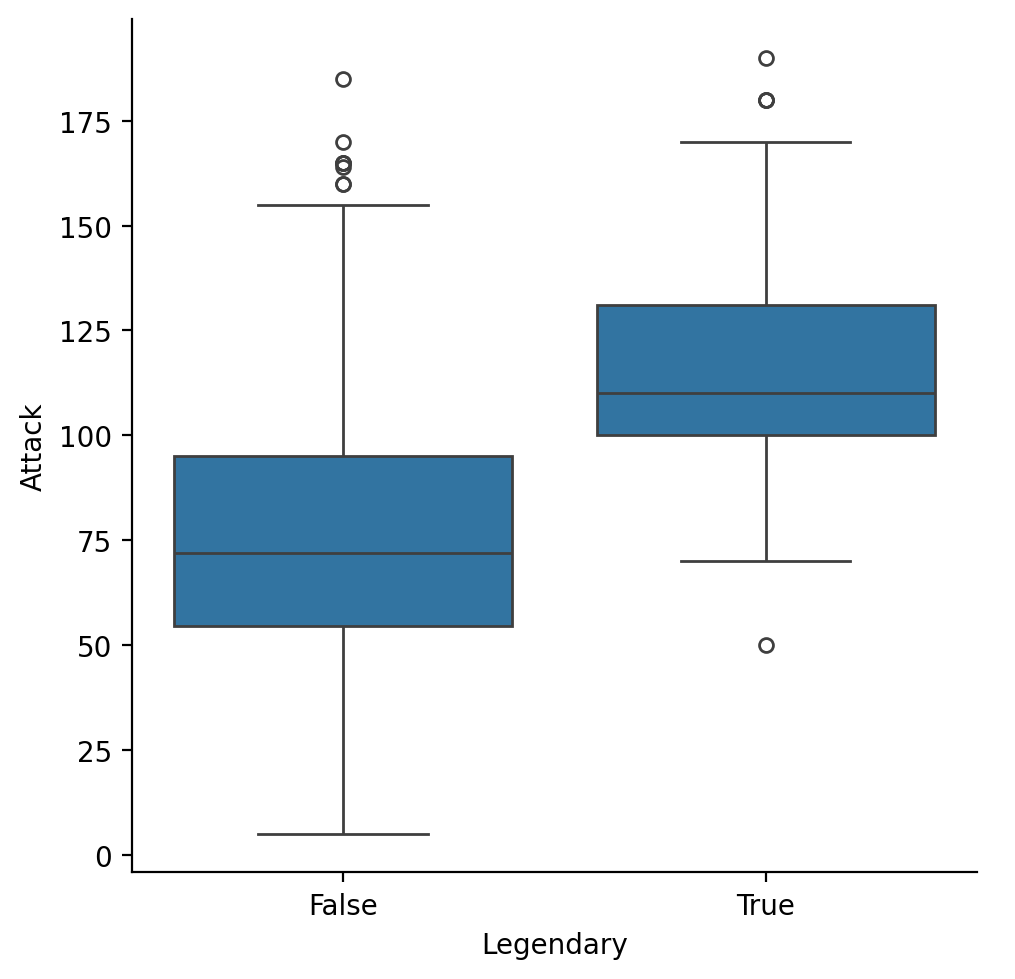

In [41]:
sns.catplot(data = df_pokemon, x = "Legendary", 
             y = "Attack", kind = "box");

Mozna łatwo oczywiście wykreślić jedną zmienną i jej wykres pudełkowy:

In [3]:
titanic = pd.read_csv('data/titanic.csv')
titanic.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


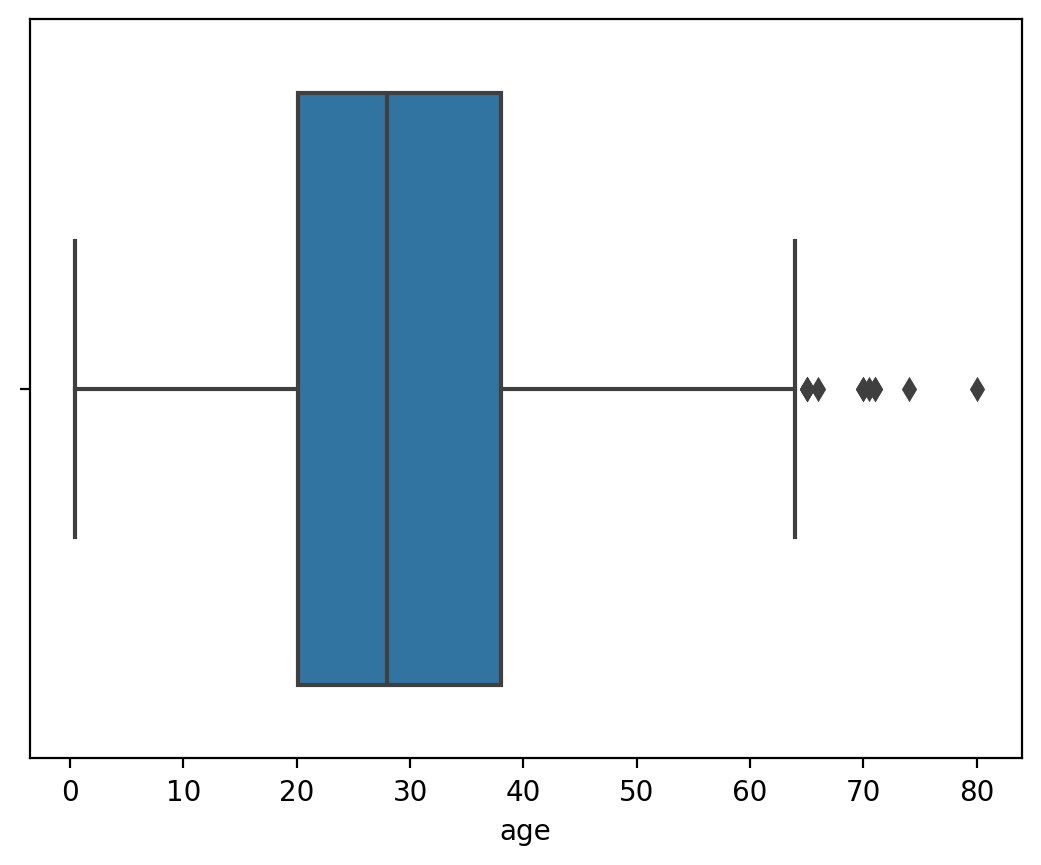

In [4]:
sns.boxplot(x=titanic["age"]);

Pogrupujemy teraz boxplot według zmiennej kategorialnej, odwołując się do kolumn w ramce danych:

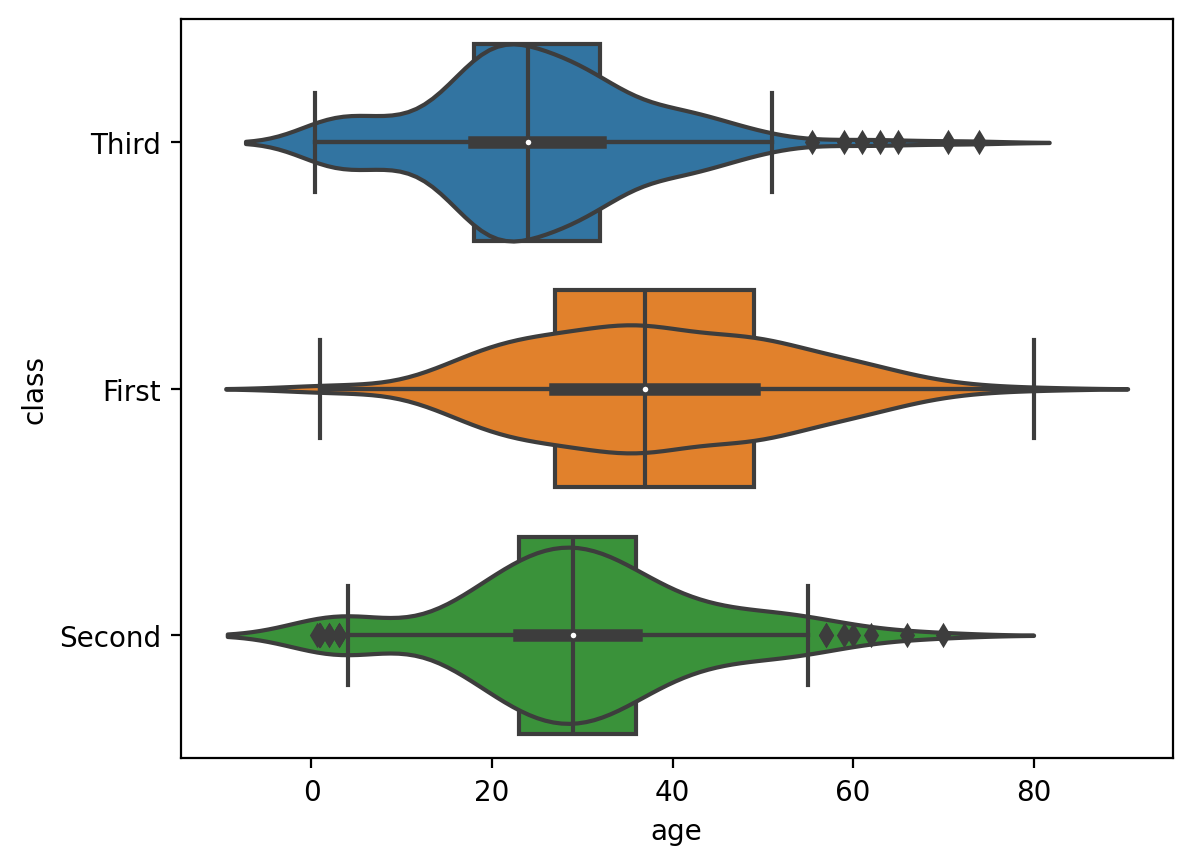

In [5]:
sns.boxplot(data=titanic, x="age", y="class");
sns.violinplot(data=titanic, x="age", y="class", alpha=0.5 );

Narysujmy pionowy wykres pudełkowy z zagnieżdżonym grupowaniem według dwóch zmiennych:

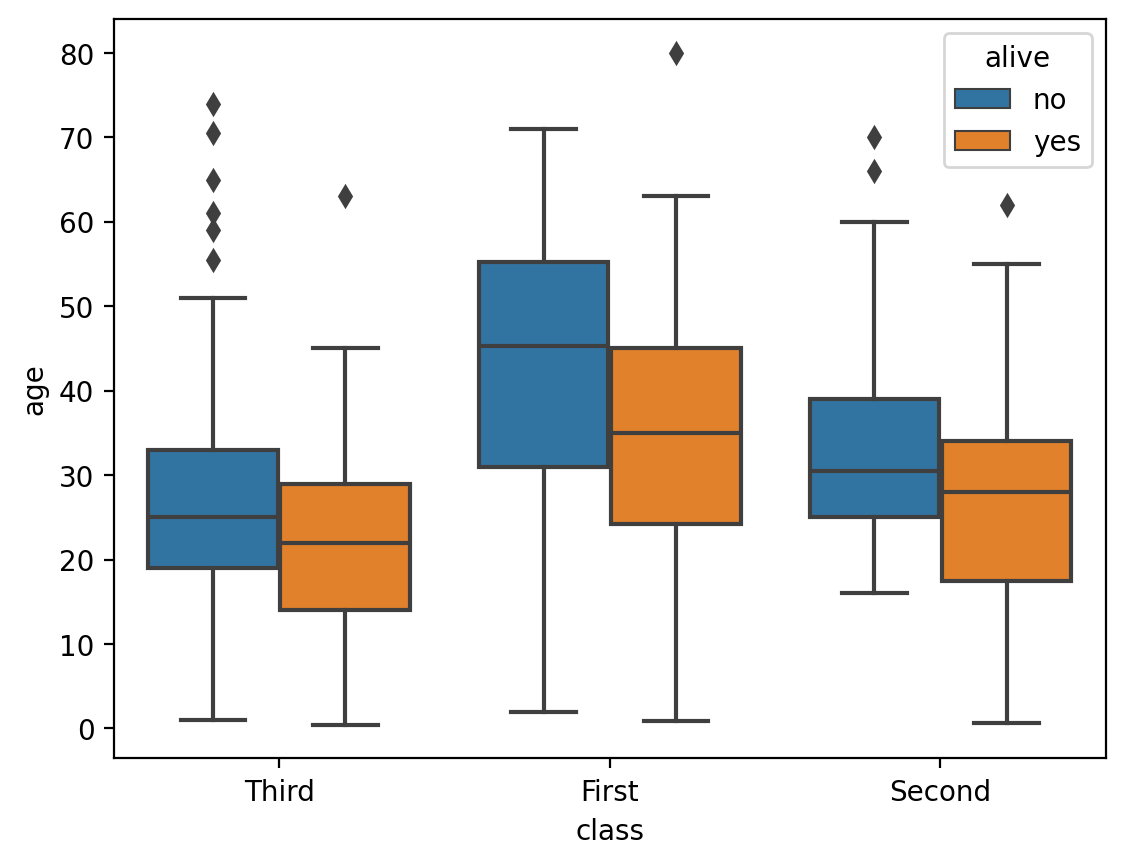

In [6]:
sns.boxplot(data=titanic, x="class", y="age", hue="alive");

Zobacz takze, jak narysować wykresy wiolinowe, wykresy tzw. roju (podobne do paskowego) - więcej informacji [tutaj](https://seaborn.pydata.org/generated/seaborn.boxplot.html).

## Grupowanie wykresów na 1 ekranie za pomocą Seaborn:

W seaborn robi się to dużo prościej niż w Matplotlibie, bo biblioteka ma wbudowane argumenty typu hue, col, row, które automatycznie dzielą dane na grupy.

In [2]:
import plotly.express as px
df = px.data.tips()
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### Histogram z podziałem na grupy

Najprostsza wersja: histogram wartości rachunku według płci.

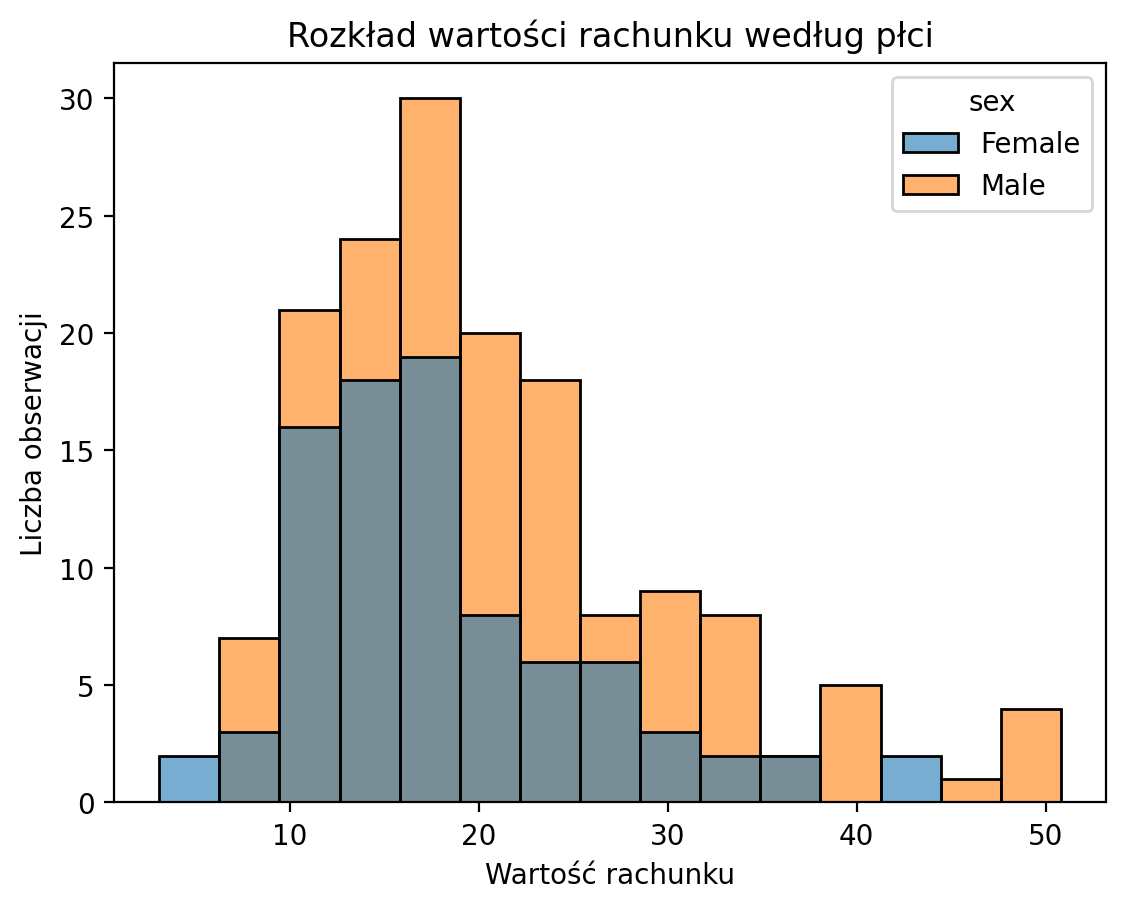

In [5]:
sns.histplot(data=df,
        x="total_bill",
        hue="sex",
        bins=15,
        alpha=0.6)

plt.xlabel("Wartość rachunku")
plt.ylabel("Liczba obserwacji")
plt.title("Rozkład wartości rachunku według płci")
plt.show()

- tutaj hue="sex" oznacza, że seaborn sam podzieli obserwacje według płci i narysuje grupy na jednym wykresie.

## Histogramy obok siebie

Jeżeli chcesz mieć osobny histogram dla każdej grupy, użyj displot() z argumentem col.

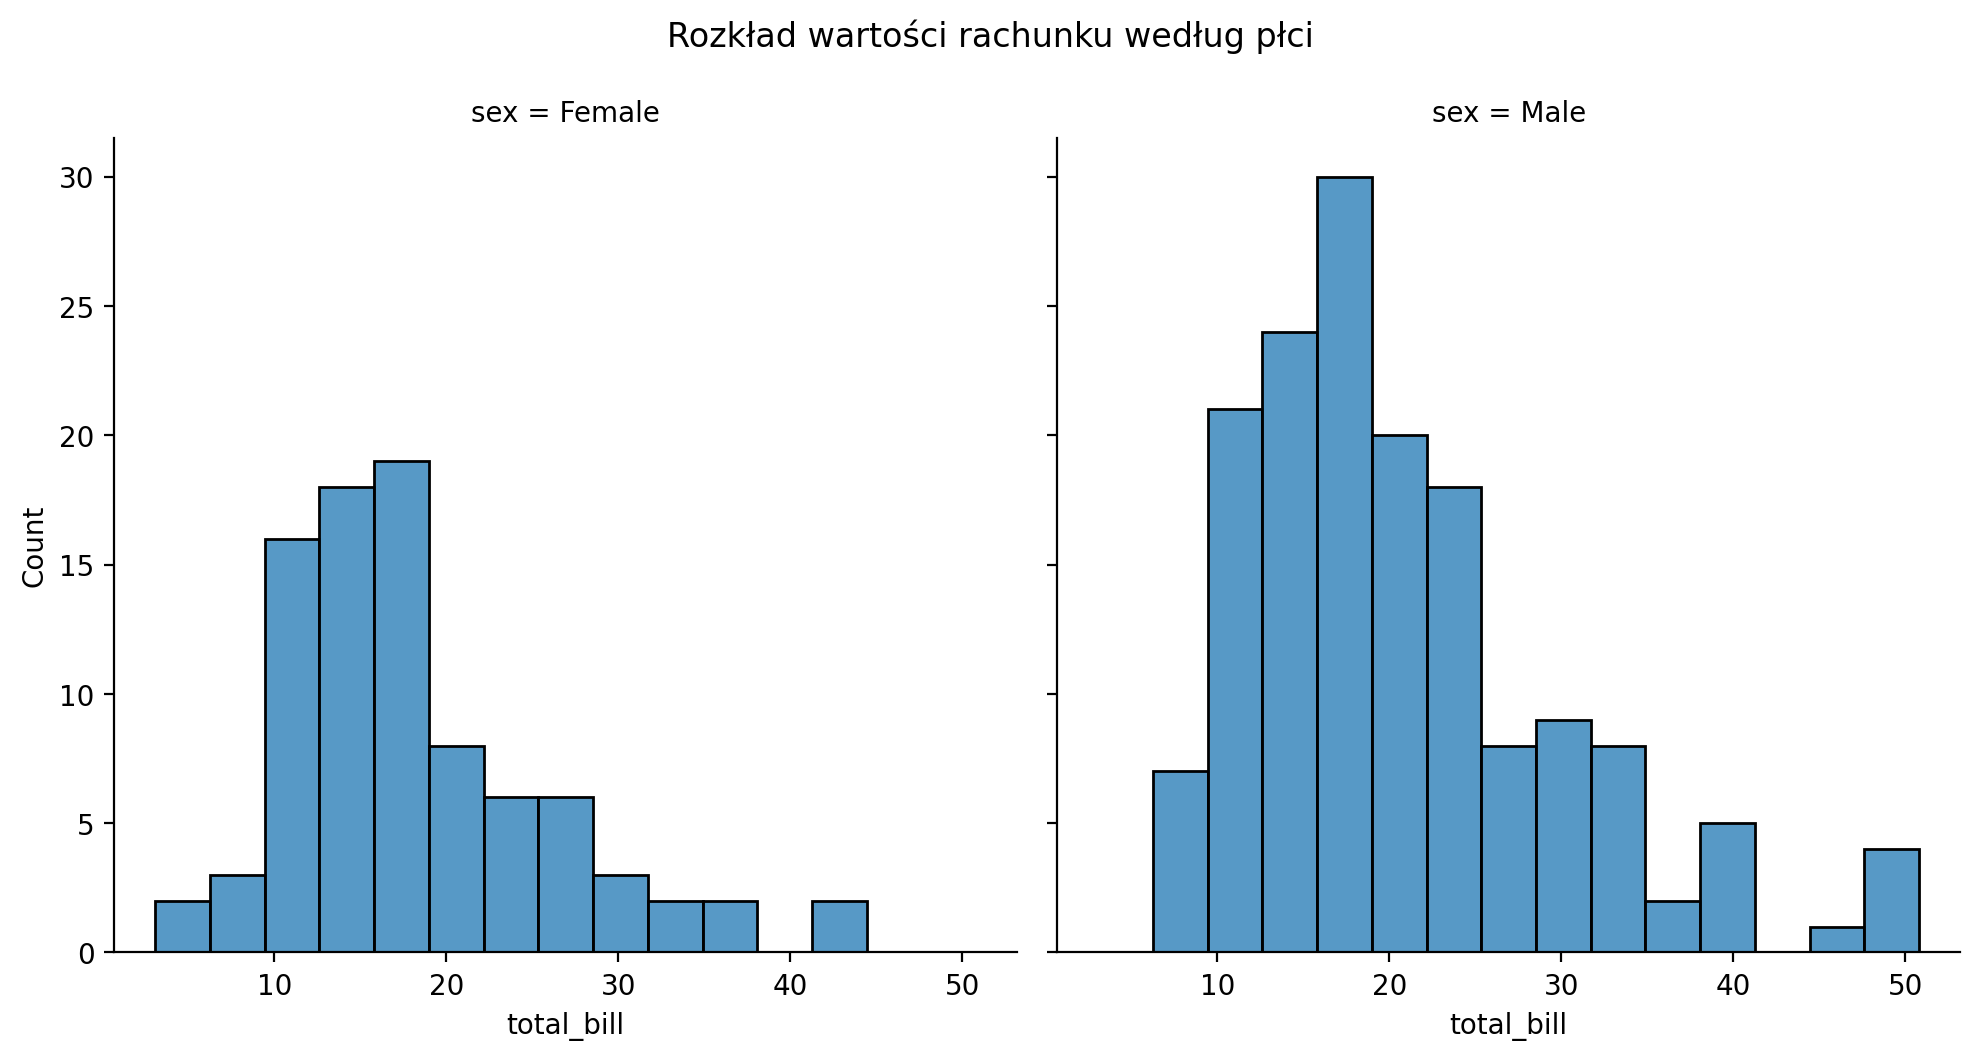

In [6]:
sns.displot(
    data=df,
    x="total_bill",
    col="sex",
    bins=15
)

plt.suptitle("Rozkład wartości rachunku według płci", y=1.05)
plt.show()

## Histogramy obok siebie z polskimi tytułami

Seaborn automatycznie pokazuje tytuły typu sex = Female, ale można je zmienić.

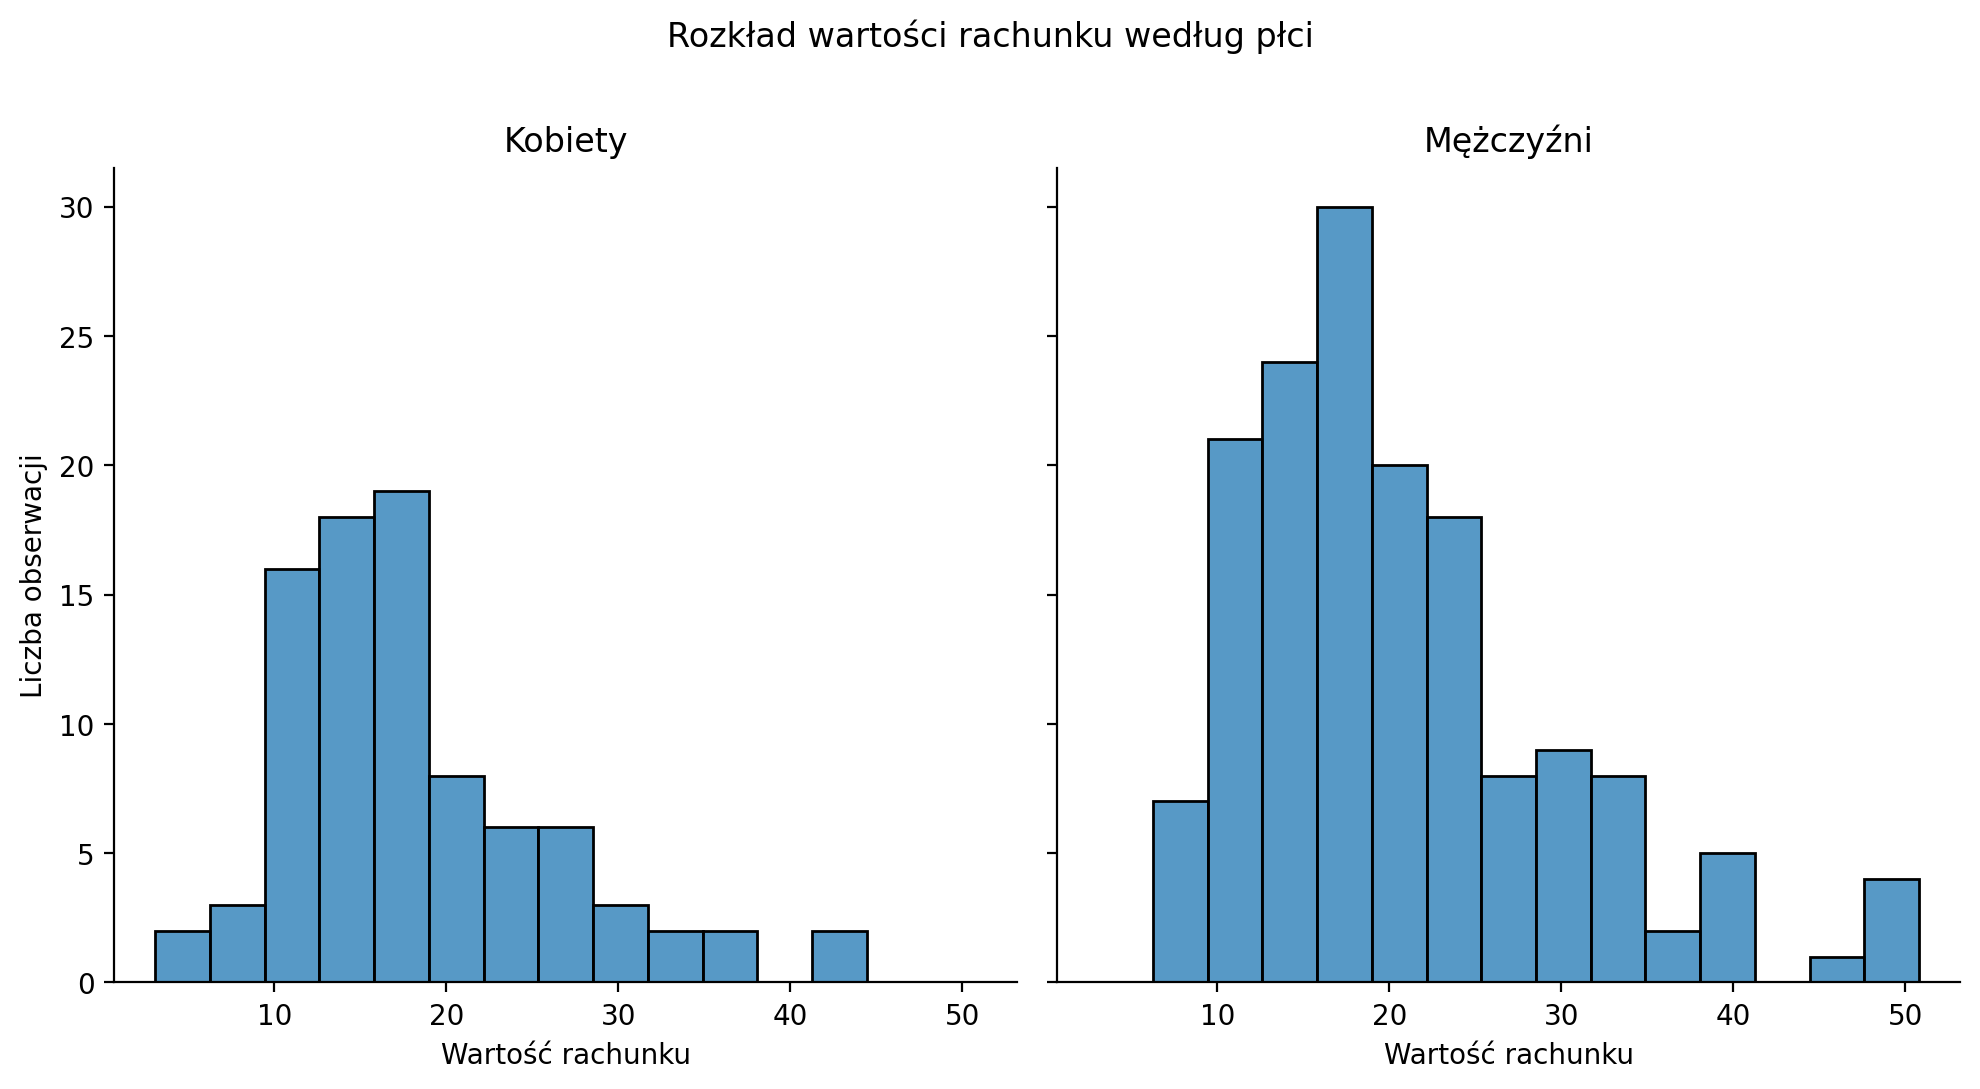

In [7]:
g = sns.displot(
    data=df,
    x="total_bill",
    col="sex",
    bins=15
)

g.set_axis_labels("Wartość rachunku", "Liczba obserwacji")
g.set_titles("{col_name}")

# ręczna zamiana tytułów
g.axes[0, 0].set_title("Kobiety")
g.axes[0, 1].set_title("Mężczyźni")

plt.suptitle("Rozkład wartości rachunku według płci", y=1.08)
plt.show()

## Wykres rozrzutu z grupami

Najprostszy wykres rozrzutu:

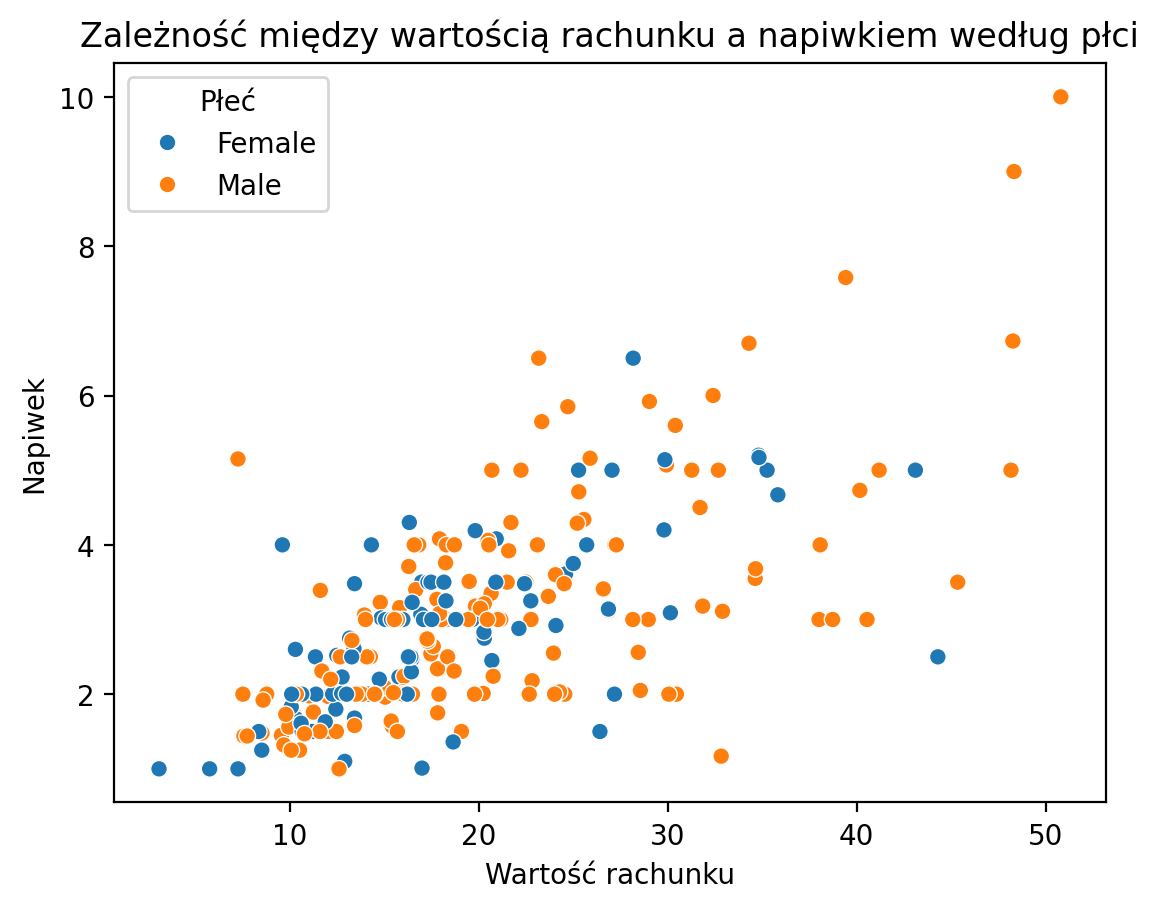

In [8]:
sns.scatterplot(
    data=df,
    x="total_bill",
    y="tip",
    hue="sex"
)

plt.xlabel("Wartość rachunku")
plt.ylabel("Napiwek")
plt.title("Zależność między wartością rachunku a napiwkiem według płci")
plt.legend(title="Płeć")
plt.show()

W seaborn nie trzeba pisać pętli: `for grupa, dane_grupy in df.groupby("sex")`. Wystarczy: `hue="sex"`.

## Dwa wykresy rozrzutu obok siebie

Do tego najlepiej użyć relplot().

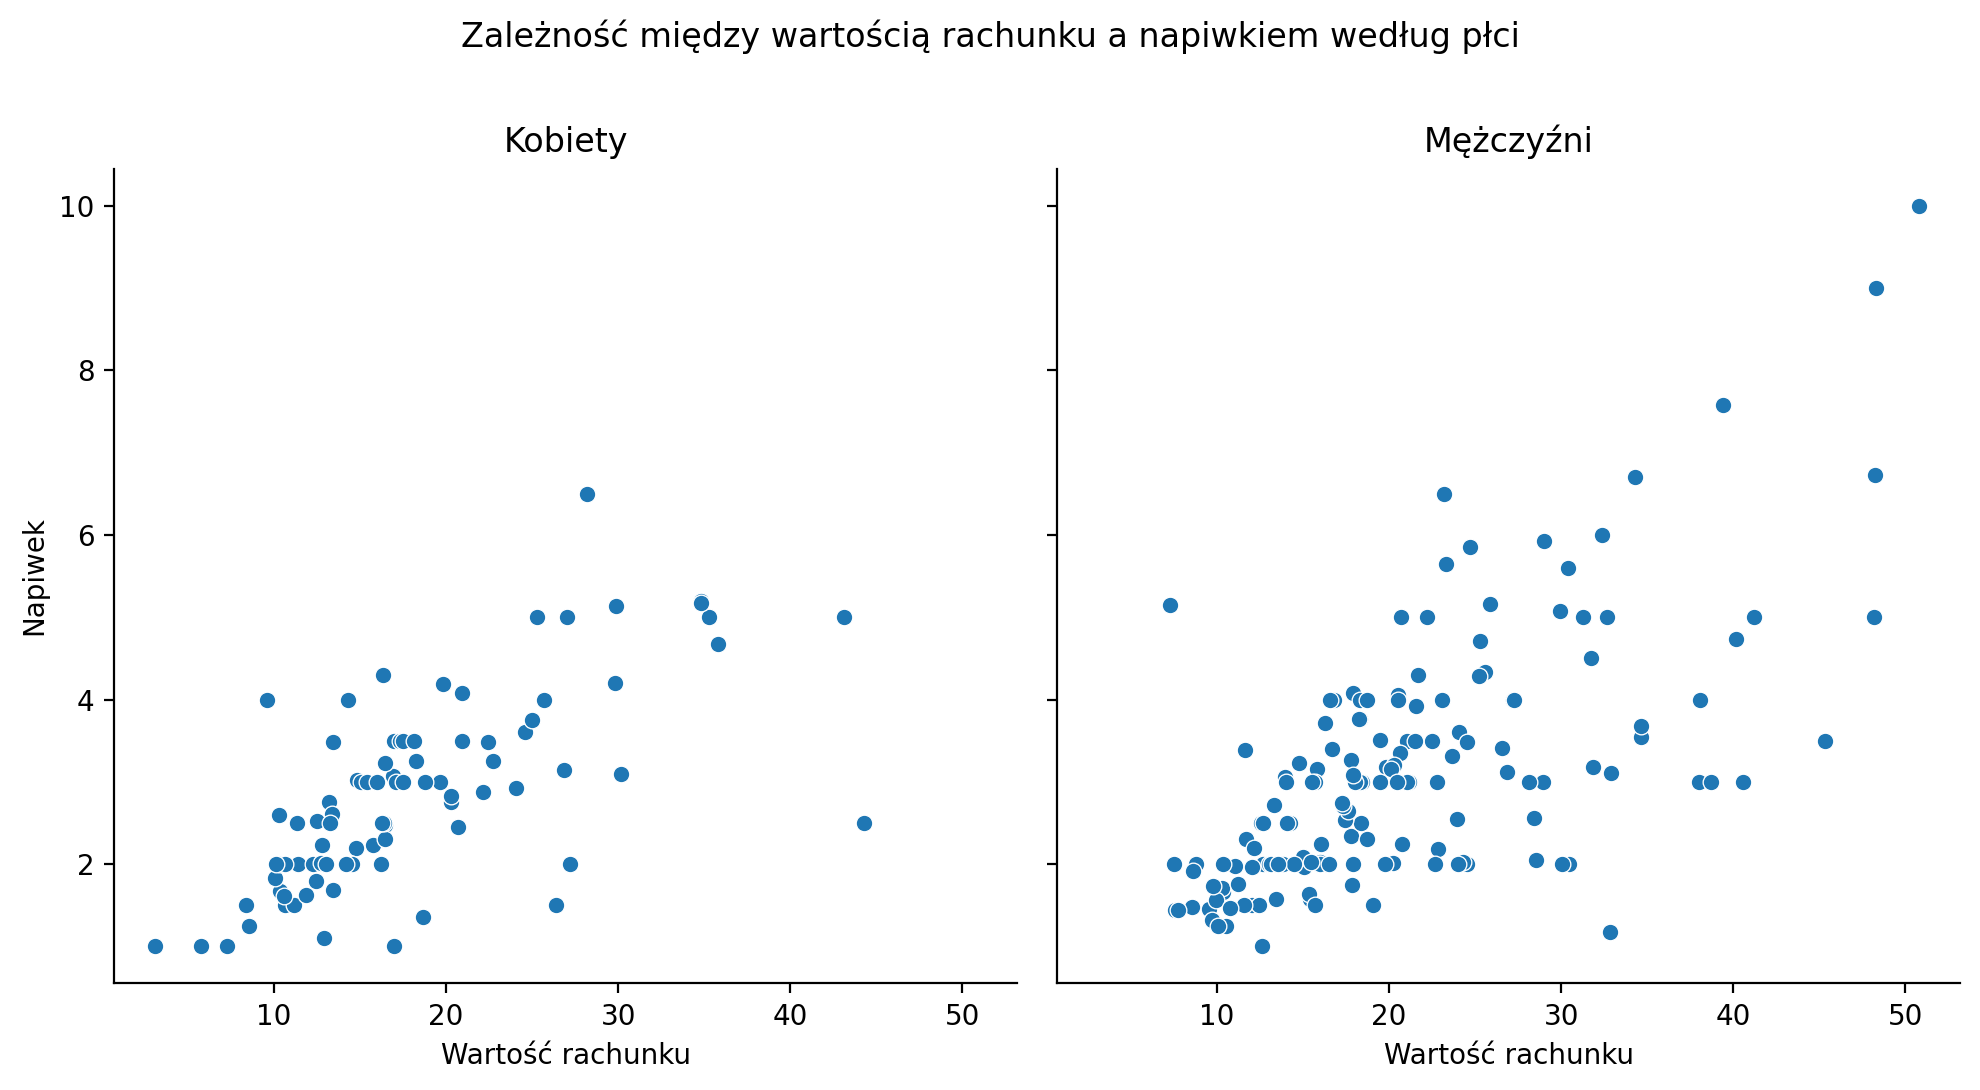

In [10]:
g = sns.relplot(
    data=df,
    x="total_bill",
    y="tip",
    col="sex",
    kind="scatter"
)

g.set_axis_labels("Wartość rachunku", "Napiwek")
g.set_titles("{col_name}")

g.axes[0, 0].set_title("Kobiety")
g.axes[0, 1].set_title("Mężczyźni")

plt.suptitle("Zależność między wartością rachunku a napiwkiem według płci", y=1.08)
plt.show()

Grupowanie po statusie palenia:

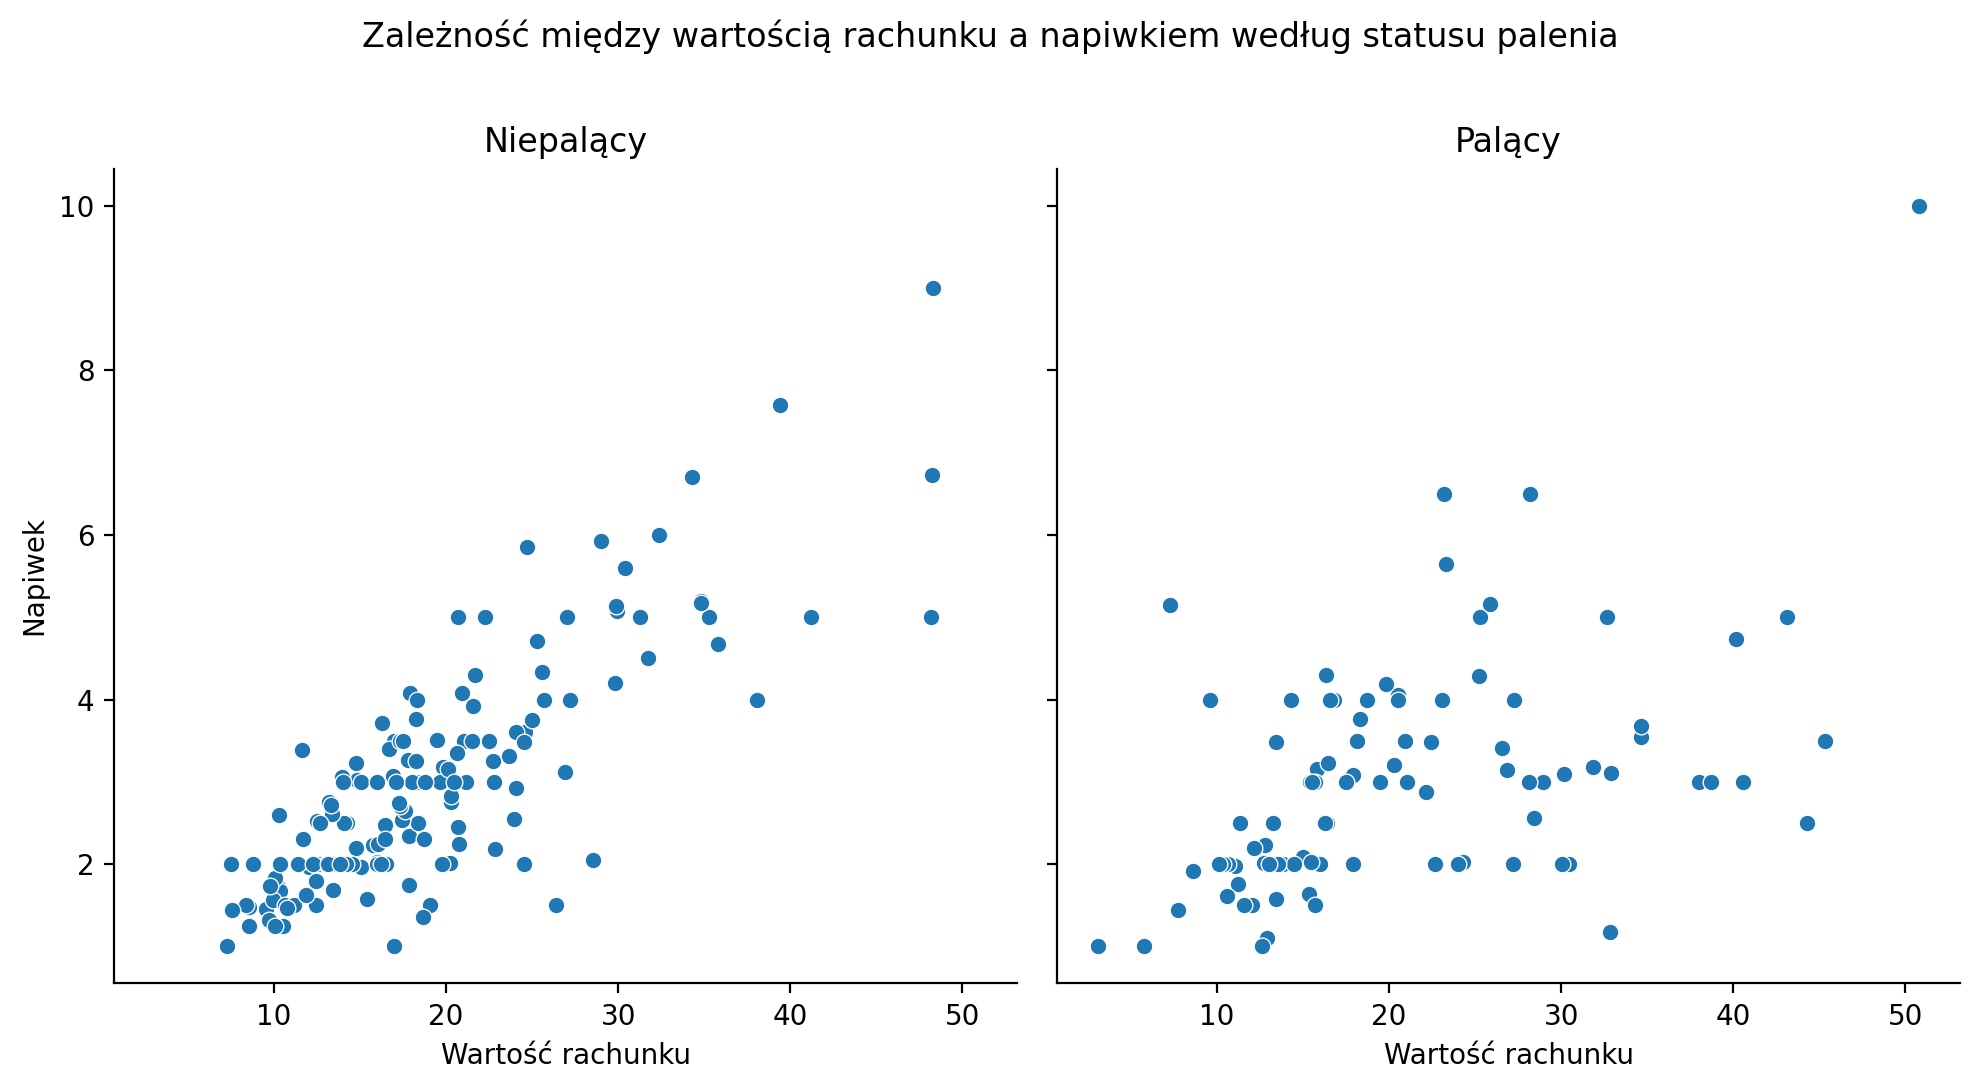

In [12]:
g = sns.relplot(
    data=df,
    x="total_bill",
    y="tip",
    col="smoker",
    kind="scatter"
)

g.set_axis_labels("Wartość rachunku", "Napiwek")
g.set_titles("{col_name}")

g.axes[0, 0].set_title("Niepalący")
g.axes[0, 1].set_title("Palący")

plt.suptitle("Zależność między wartością rachunku a napiwkiem według statusu palenia", y=1.08)
plt.show()

## Grupowanie po dwóch zmiennych

Na przykład kolor punktów według płci, a osobne wykresy według statusu palenia:

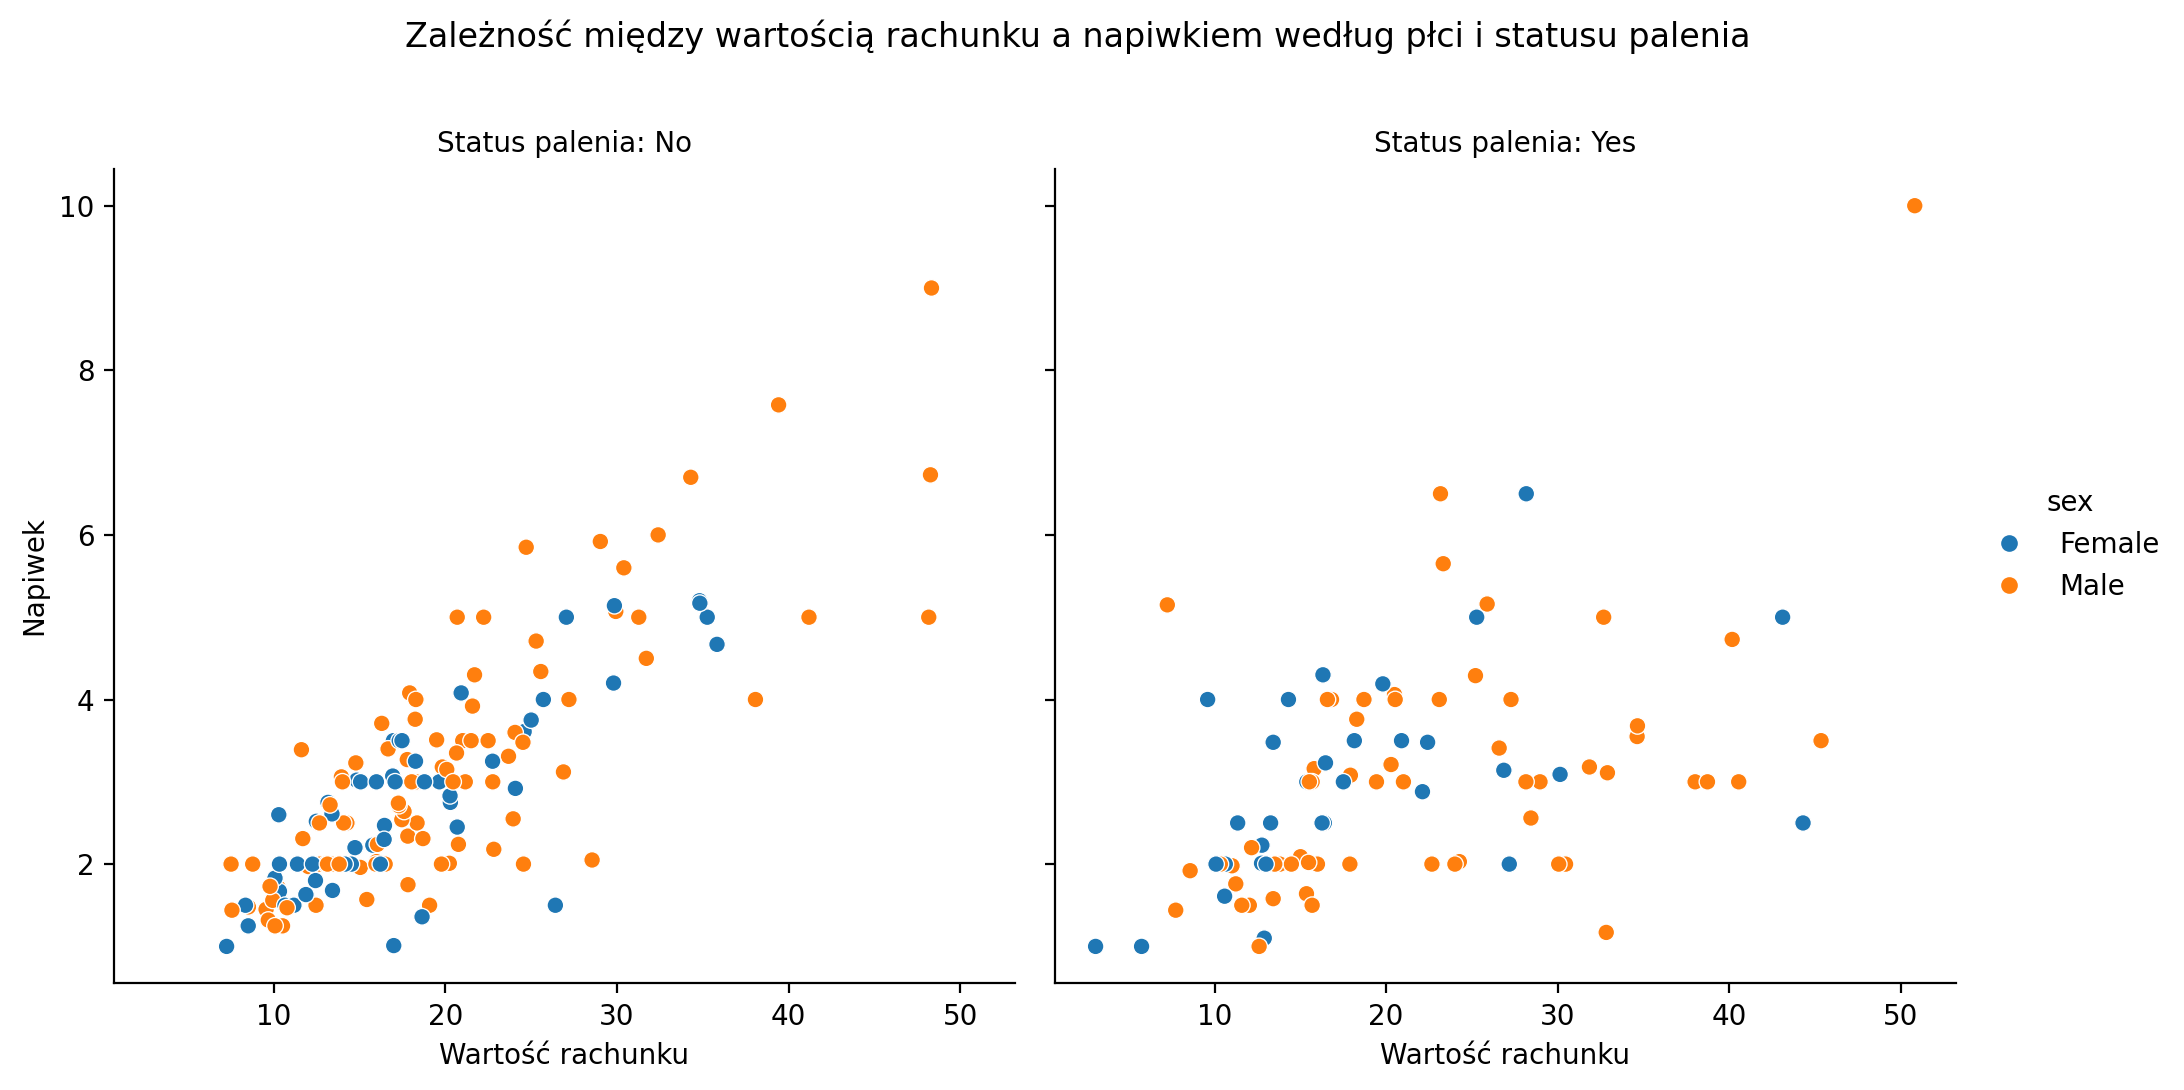

In [13]:
g = sns.relplot(
    data=df,
    x="total_bill",
    y="tip",
    hue="sex",
    col="smoker",
    kind="scatter"
)

g.set_axis_labels("Wartość rachunku", "Napiwek")
g.set_titles("Status palenia: {col_name}")

plt.suptitle("Zależność między wartością rachunku a napiwkiem według płci i statusu palenia", y=1.08)
plt.show()

To jest jedna z największych zalet seaborn: można bardzo łatwo dodawać kolejne wymiary:
- hue="sex"      # kolor według płci
- col="smoker"  # osobne wykresy według statusu palenia
- row="time"    # osobne wiersze według pory posiłku

### Przykład z row i col

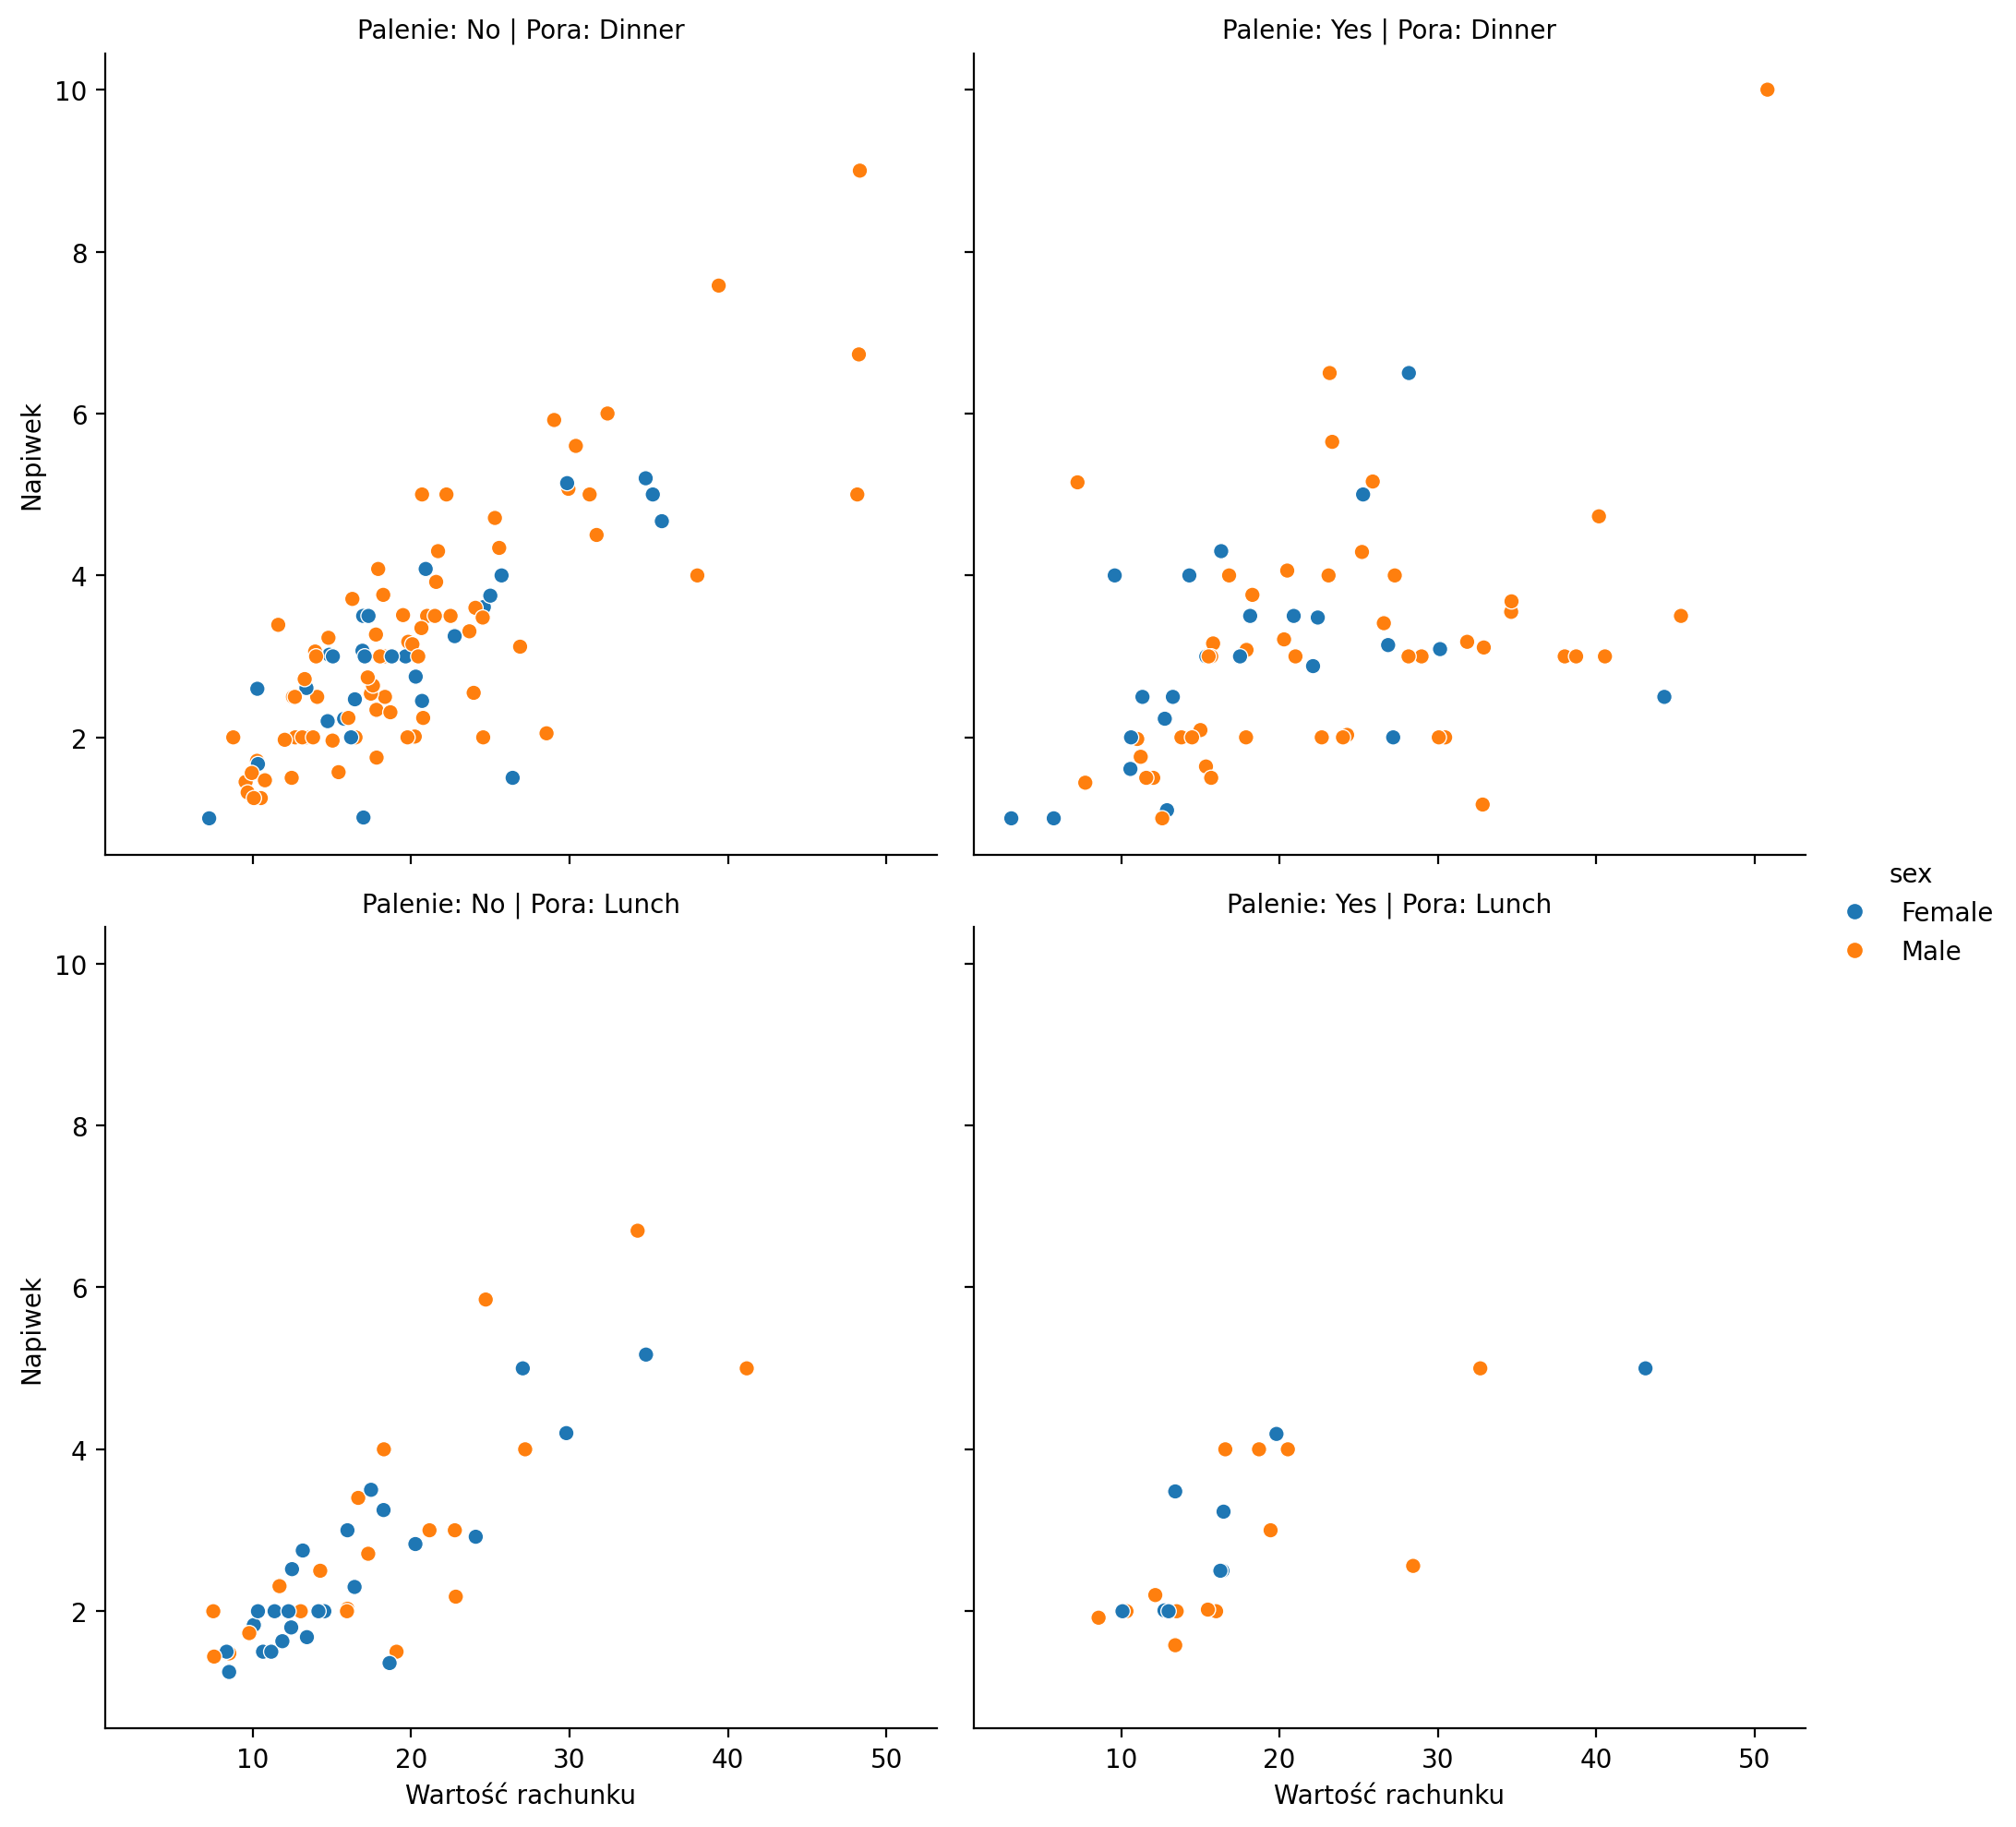

In [14]:
g = sns.relplot(
    data=df,
    x="total_bill",
    y="tip",
    hue="sex",
    col="smoker",
    row="time",
    kind="scatter"
)

g.set_axis_labels("Wartość rachunku", "Napiwek")
g.set_titles("Palenie: {col_name} | Pora: {row_name}")

plt.show()

Najważniejsza różnica! W Matplotlib często piszesz pętlę:

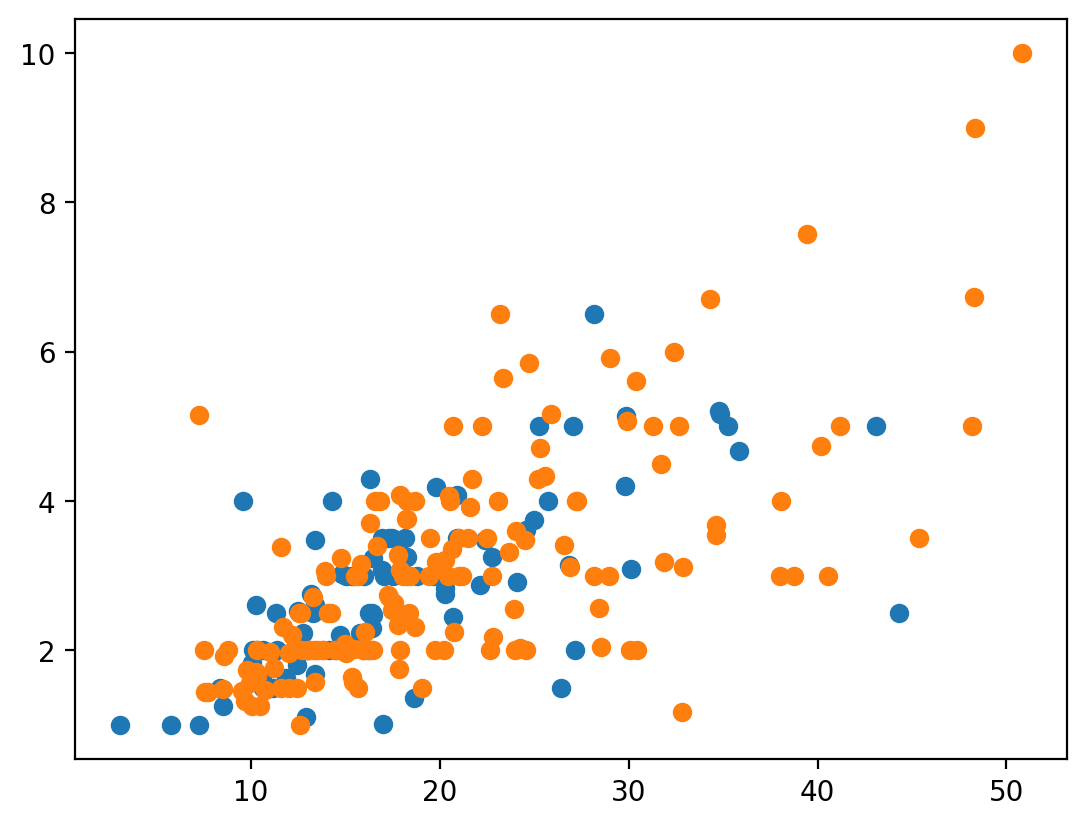

In [15]:
for grupa, dane_grupy in df.groupby("sex"):
    plt.scatter(
        dane_grupy["total_bill"],
        dane_grupy["tip"],
        label=grupa
    )

W seaborn robisz to krócej:

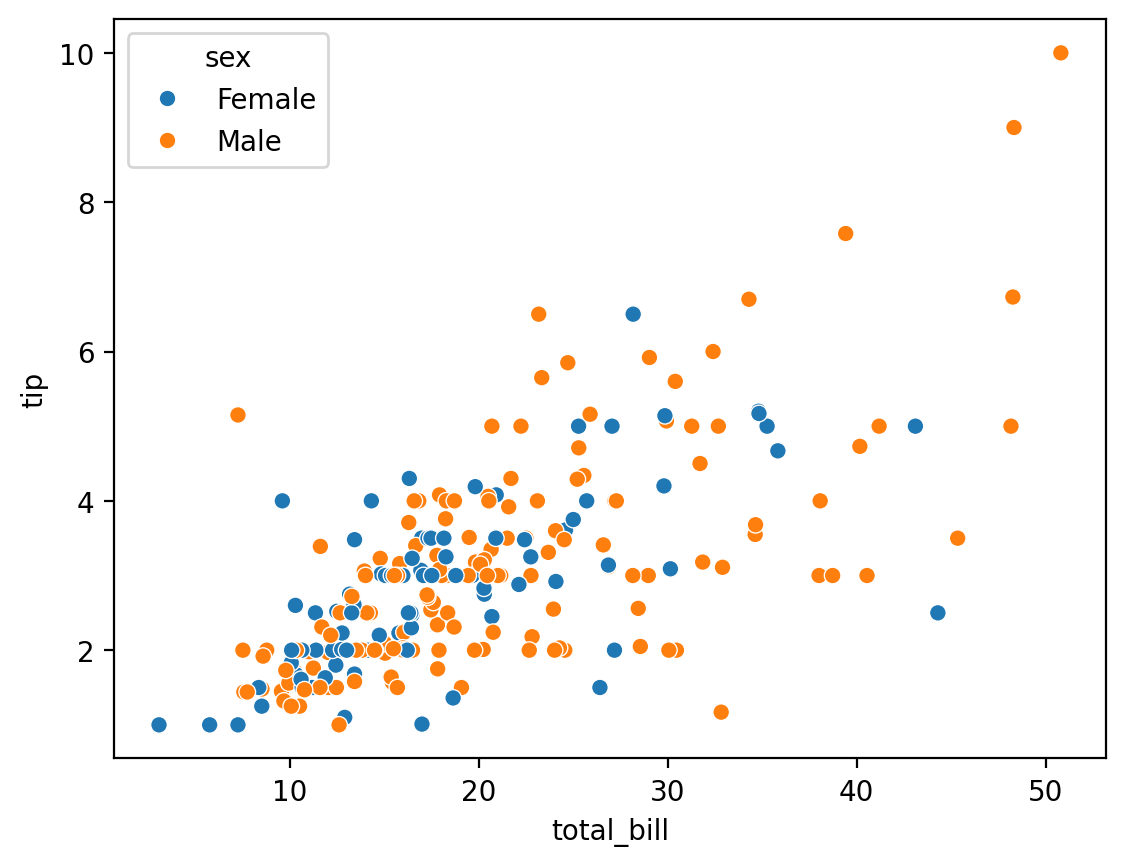

In [17]:
wykres = sns.scatterplot(
    data=df,
    x="total_bill",
    y="tip",
    hue="sex"
)

Czyli najważniejsze argumenty do zapamiętania:

- hue = kolorowanie według grupy
- col = osobne wykresy w kolumnach
- row = osobne wykresy w wierszach
- style = różne style punktów
- size = różne rozmiary punktów

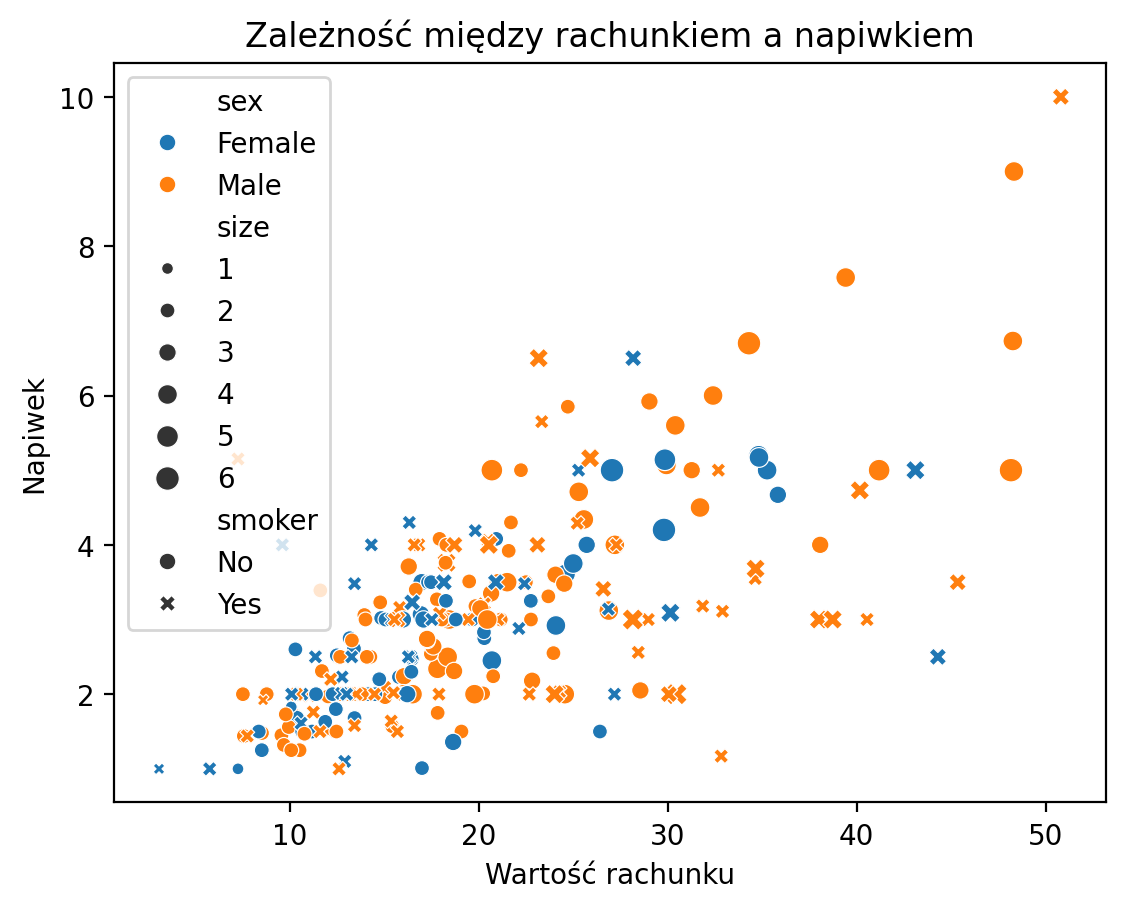

In [18]:
sns.scatterplot(
    data=df,
    x="total_bill",
    y="tip",
    hue="sex",
    style="smoker",
    size="size"
)

plt.xlabel("Wartość rachunku")
plt.ylabel("Napiwek")
plt.title("Zależność między rachunkiem a napiwkiem")
plt.show()

## Podsumowanie

Były to dwa rozdziały o wizualizacji danych na początek - absolutne minimum, aby zacząć wykonywać eksploracyjną analizę danych.

W szczególności, w tym rozdziale było to wprowadzenie do:

- Pakietu `seaborn`.
- Wykreślania danych **jednowymiarowych** i **różnowymiarowych**.
- Tworzenia wykresów z wieloma warstwami.